[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/reinhart-group/generative-copolymer-workshop/blob/main/day1/03_feature_extraction.ipynb)

# Day 1, Afternoon: From Configurations to Features

Today's topics:
* Equilibration diagnostics: when is a measurement trustworthy?
* Classical descriptors and the degeneracy problem ($R_g$ from scratch)
* What makes a good structural representation: invariances, completeness, compactness
* Structures as images: convolution, CNNs, and transfer learning
* The 1280-dimensional fingerprint

*Where we are in the pipeline:* Notebooks 01 and 02 gave us MD trajectories.
Today we turn each equilibrated structure into one fingerprint $x \in \mathbb{R}^{1280}$ that Day 2 embeds and Day 2's surrogate learns to predict.

*What do we actually have so far?*

Notebooks 01 and 02 gave us trajectories: raw particle positions, snapshot after snapshot.
That is not yet something we can compare.
You can't ask "is this more like a sphere or a string?" of a coordinate list.

We'll get there in three steps.

1. Check whether the data is worth measuring at all (equilibration).
2. Try the obvious descriptor, $R_g$, and find where it goes blind.
3. Build a learned representation instead: render each structure as an image and let a pretrained CNN describe it.

The result is one 1280-number fingerprint per structure.
That is what Day 2 loads by the thousands and folds into a 2-D map.

*Why does this notebook install so much?*

We regenerate our own diblock and alternating trajectories below, so we need the same conda-forge HOOMD stack as notebooks 01 and 02.
That install goes first, because it restarts the runtime.

Installing conda replaces the Python that Colab started with.
`torch` and `torchvision` ship with a stock Colab runtime but are not in the fresh environment, so we reinstall them in the third cell.

In [ ]:
#@title  ⚙️  Step 1 of 2 — install conda (causes a restart; that's normal). { display-mode: "form" }
# Guarded so this cell is safe to re-run. Once condacolab has converted the runtime, the
# Python it installs (3.12) has no `distutils`, which condacolab itself imports -- so a
# student who hits "Runtime -> Restart session" and re-runs from the top would otherwise get
# a baffling `ModuleNotFoundError: No module named 'distutils'` instead of a no-op.
import os
if os.path.exists('/usr/local/bin/conda'):
    print('✅ conda is already installed on this runtime — skipping (no restart needed).')
else:
    !pip install -q condacolab
    import condacolab
    condacolab.install()   # this restarts the kernel; the notebook continues from Step 2

In [ ]:
#@title  ⚙️  Step 2 of 2 — install the simulation + drawing packages (~2 min). { display-mode: "form" }
# NOTE TO INSTRUCTORS: do NOT put `%%capture` (or any %% cell magic) below this line.
# A cell magic must be the FIRST line of the cell, and line 1 here is the #@title form
# header — so `%%capture` on line 2 is parsed as a *line* magic, raises UsageError, and
# silently skips the entire install. We shipped exactly that bug once; the conda output
# stays visible on purpose, because a solver failure here is what you need to see.
!conda install -y -q python=3.12 scipy gsd "hoomd=*=cpu*" freud fresnel pillow
!pip install -q plotly "nbformat>=4.2.0"   # nbformat: lets plotly emit its mimetype bundle (VS Code/JupyterLab)

# Python caches the contents of every sys.path directory at interpreter start, so packages
# conda just created are invisible to `import` until those caches are dropped. Without this
# the verification below fails with ModuleNotFoundError even though the install succeeded.
import importlib
importlib.invalidate_caches()

import hoomd, gsd, freud, fresnel
print(f'✅ simulation stack ready — HOOMD-blue {hoomd.version.version}, freud {freud.__version__}')

In [ ]:
#@title  ⚙️  Also install the neural-network packages (~1 min). { display-mode: "form" }
# condacolab replaces the Colab Python, so torch/torchvision are no longer present
# even though a stock Colab runtime ships them. Reinstall into the new environment.
!pip install -q torch torchvision

In [5]:
#@title  ⚙️  Setup — build the workshop workspace (Colab). { display-mode: "form" }
# The "Open in Colab" badge loads ONLY this .ipynb into a bare VM at /content, so the
# directory layout this notebook reads by relative path -- ../data (derived tables) and
# ../models (the trained surrogate) -- does not exist yet. We do NOT clone the repo: every
# data and model artifact is published in the Zenodo bundle (concept DOI 10.5281/zenodo.21382941,
# which always resolves to the latest version),
# which is public and sha256-verified, and the helper code is spliced into this notebook.
# So this cell just creates the workspace and steps into the day directory; the
# `ensure_bundle(...)` calls further down fetch the actual data into ../data on first use.
#
# Idempotent, and a no-op if you are already running from a repo checkout (instructors).
import os, sys

WORKSPACE = os.environ.get('CDSE_WORKSPACE', '/content/cdse-workshop')
DAY_DIR = 'day1'

if os.path.isdir('../data') and os.path.isdir('../campaign'):
    print(f'✅ already inside a workshop checkout — cwd={os.getcwd()}')
else:
    for sub in ('data', 'models', DAY_DIR):
        os.makedirs(os.path.join(WORKSPACE, sub), exist_ok=True)
    os.chdir(os.path.join(WORKSPACE, DAY_DIR))
    print(f'✅ workspace ready — cwd={os.getcwd()}')
    print('   ../data and ../models will be filled from Zenodo by the ensure_bundle() calls below.')

✅ already inside a workshop checkout — cwd=/Users/giraffe/Code/cdse/generative-copolymer-workshop/day1


In [6]:
#@title  ⚙️  cdse_lab — shared plotting/IO helpers for Day 1. You can ignore this cell. { display-mode: "form" }
#
# This module intentionally contains NO simulation code. HOOMD snapshot setup,
# integrators, thermostats, and forces are written out directly in each notebook
# (01_md_simulation, 02_virtual_lab) -- seeing that code is the lesson. This
# module only hides generic, non-pedagogical plumbing:
#
#     Trajectory                              -- a lightweight "movie": frames + times
#     grab_frame(snapshot)                    -- capture a HOOMD/GSD snapshot into a frame dict
#     unwrap(frame)                           -- undo periodic wrapping (image flags -> continuous coords)
#     save_gsd(traj, filename) / load_gsd(f)  -- write / read a real .gsd file
#     show3d(frame_or_traj) / animate3d(traj) -- interactive 3D picture / movie (Plotly)
#     show_row(*figs)                         -- lay several show3d/animate3d figures side by side
#     measure_size(traj)                      -- largest B-bead aggregate (cluster) size vs. time
#     render_pretty(frame_or_traj)            -- optional ray-traced still (needs fresnel)
#
#     show3d/animate3d/render_pretty all take wrap=False (default): pass wrap=True to
#     keep every bead inside the box instead of unwrap()'ing, which is the better view
#     for diffuse aggregates (unwrapping can smear one apart and make it look less
#     clustered than it is). Bonds that cross the boundary are drawn as two stubs out to
#     the opposite walls, so neither setting ever rakes a bond across the box.
#
# Forked from reu/cdse_lab.py (a separate, unrelated curriculum) -- this copy is
# scoped to the workshop and does not track that file.

import sys

import numpy as np
import gsd.hoomd

try:
    import plotly.graph_objects as go
except ImportError:
    # plotly is only needed for the interactive viz helpers (show3d/animate3d/
    # show_row). The Trajectory/grab_frame/save_gsd/load_gsd IO helpers work
    # without it, so the sim-campaign compute path can run in a plotly-free env.
    go = None


def _ensure_inline_renderer():
    """Make `fig.show()` render *inline*, whatever front end we're in.

    Colab auto-selects its own 'colab' renderer -- leave that alone. Outside Colab, plotly
    guesses from the environment and falls back to 'browser' when it cannot tell (a kernel
    launched outside the editor, or a remote kernel). 'browser' tries to open a tab on the
    *kernel* host, which is a no-op over a remote kernel and impossible on a Colab VM -- that
    is the "show3d/animate3d silently stopped working" symptom. So: never leave 'browser'
    selected inside a notebook, and never hard-code it (that would break Colab for everyone).
    'plotly_mimetype+notebook_connected' emits both a mimetype bundle (VS Code, JupyterLab)
    and a CDN <script> block (anything that renders HTML), covering every front end we ship to.
    """
    if go is None:
        return
    if "google.colab" in sys.modules:          # Colab knows best
        return
    try:
        get_ipython                            # noqa: F821 -- only bound under IPython
    except NameError:
        return                                 # plain script: 'browser' is the right default
    import plotly.io as pio
    if "browser" in str(pio.renderers.default):
        pio.renderers.default = "plotly_mimetype+notebook_connected"


_ensure_inline_renderer()

# Colors: type "A" = blue (slippery), type "B" = red (sticky)
_A_COLOR = "royalblue"
_B_COLOR = "crimson"

__all__ = [
    "Trajectory", "grab_frame", "unwrap",
    "save_gsd", "load_gsd",
    "show3d", "show_row", "animate3d", "measure_size", "render_pretty",
]


def _typeids_to_seq(typeids):
    """Inverse of the 'A'/'B' -> 0/1 encoding, for one chain's worth of typeids."""
    return "".join("A" if int(t) == 0 else "B" for t in typeids)


class Trajectory:
    """A lightweight 'movie': a list of frames plus a little bookkeeping.

    Each frame is a dict with:
        position : (N,3) float  -- WRAPPED coordinates (inside the box), as in a real GSD
        image    : (N,3) int    -- how many box-lengths each particle has wandered
        typeid   : (N,)  int     -- 0 = A, 1 = B
        bonds    : (M,2) int     -- pairs of bonded particle indices
        box      : (3,)  float   -- box edge lengths (Lx, Ly, Lz)
    Use unwrap(frame) to get continuous (un-wrapped) coordinates.
    """

    def __init__(self, sequence, num_chains):
        self.sequence = sequence
        self.num_chains = num_chains
        self.chain_len = len(sequence)
        self.frames = []
        self.times = []

    def __len__(self):
        return len(self.frames)

    def __getitem__(self, i):
        return self.frames[i]

    def __repr__(self):
        return (f"Trajectory(sequence={self.sequence!r}, num_chains={self.num_chains}, "
                f"frames={len(self.frames)})")


def grab_frame(snapshot):
    """Copy the bits we need out of a HOOMD/GSD snapshot (wrapped coords + image flags).

    A freshly hand-built gsd.hoomd.Frame may have no image flags yet; we default
    them to zeros (every particle in its home box).
    """
    N = int(snapshot.particles.N)
    image = snapshot.particles.image
    image = (np.zeros((N, 3), dtype=int) if image is None
             else np.array(image, dtype=int))
    return {
        "position": np.array(snapshot.particles.position, dtype=float),
        "image": image,
        "typeid": np.array(snapshot.particles.typeid, dtype=int),
        "bonds": (np.array(snapshot.bonds.group, dtype=int)
                  if snapshot.bonds.N else np.zeros((0, 2), int)),
        "box": np.array(snapshot.configuration.box[:3], dtype=float),
    }


def unwrap(frame):
    """Return continuous (un-wrapped) coordinates, repairing bad image flags on the way.

    ("image flags" here are the integer periodic-wrap counters HOOMD stores per particle
    -- nothing to do with the rendered KDE pictures also called images in this project.)

    HOOMD stores every particle *inside* the box (wrapped) plus an integer flag counting how
    many box-lengths it has crossed, so `position + image * box` is normally the continuous
    coordinate. That formula is only as good as the flags, and for the random-walk-init
    (rwinit) arm they are wrong: `campaign/simulate_rw.py` wraps each freshly built chain
    into the box but never assigns the matching flags, so a chain laid across the boundary
    starts life with a flag of zero. HOOMD then only *increments* from that wrong start, so
    the error is permanent -- measured on rwinit shards, ~6% of bonds appear up to 32 units
    long in a box of 23.5, at every frame including the last. The grid arm is unaffected
    because its builder never wraps at initialization.

    So rather than trust the flags, walk the bond graph and require every bonded pair to sit
    within a minimum image of each other, which is the one thing physics guarantees (bonds
    are ~1 unit, the box half-width is ~11.75). Each connected chain is rebuilt from its
    lowest-index bead outwards, that root keeping its stored flag so genuine diffusion over
    the run is preserved rather than re-anchored every frame.

    When the flags are already right this changes nothing -- every correction term is
    exactly zero -- so both arms go through one code path. Frames with no bond topology
    fall back to the plain formula, since connectivity is what makes the repair well defined.
    """
    pos = frame["position"] + frame["image"] * frame["box"]
    bonds = np.asarray(frame.get("bonds") if hasattr(frame, "get") else frame["bonds"])
    if bonds is None or not len(bonds):
        return pos

    L = np.asarray(frame["box"], dtype=float)
    bonds = bonds.reshape(-1, 2)
    neighbours = [[] for _ in range(len(pos))]
    for a, b in bonds:
        neighbours[a].append(b)
        neighbours[b].append(a)

    out = np.array(pos, dtype=float)
    seen = np.zeros(len(pos), dtype=bool)
    for root in range(len(pos)):
        if seen[root]:
            continue
        seen[root] = True
        stack = [root]
        while stack:                                # walk this chain outward from its root
            u = stack.pop()
            for v in neighbours[u]:
                if seen[v]:
                    continue
                seen[v] = True
                d = pos[v] - pos[u]
                out[v] = out[u] + (d - np.round(d / L) * L)
                stack.append(v)
    return out


# --------------------------------------------------------------------------- #
#  GSD files
# --------------------------------------------------------------------------- #
def save_gsd(traj, filename):
    """Write a Trajectory to a real HOOMD GSD file.

    Static topology (types, bonds) is stored once in frame 0; per-particle
    positions and image flags are stored every frame, exactly like HOOMD does.
    """
    with gsd.hoomd.open(name=filename, mode="w") as gsd_file:
        for i, fr in enumerate(traj.frames):
            f = gsd.hoomd.Frame()
            f.configuration.step = int(traj.times[i])
            L = fr["box"]
            f.configuration.box = [L[0], L[1], L[2], 0, 0, 0]
            f.particles.N = int(len(fr["position"]))
            f.particles.position = fr["position"]
            f.particles.image = fr["image"]
            f.particles.typeid = fr["typeid"]
            if i == 0:
                f.particles.types = ["A", "B"]
                nb = int(len(fr["bonds"]))
                f.bonds.N = nb
                f.bonds.types = ["bond"]
                if nb:
                    f.bonds.group = fr["bonds"]
                    f.bonds.typeid = np.zeros(nb, dtype=int)
            gsd_file.append(f)
    return filename


def load_gsd(filename):
    """Read a HOOMD GSD file back into a Trajectory.

    Reconstructs the sequence and chain count from the topology (works for the
    linear chains this course uses: num_chains = N - n_bonds, chain_len = N / num_chains).
    """
    with gsd.hoomd.open(name=filename, mode="r") as gsd_file:
        first = gsd_file[0]
        N = int(first.particles.N)
        bonds0 = (np.array(first.bonds.group, dtype=int)
                  if first.bonds.N else np.zeros((0, 2), int))
        n_bonds = len(bonds0)
        num_chains = max(1, N - n_bonds)
        chain_len = N // num_chains
        typeid0 = np.array(first.particles.typeid, dtype=int)
        sequence = _typeids_to_seq(typeid0[:chain_len])

        traj = Trajectory(sequence, num_chains)
        for frame in gsd_file:
            box = np.array(frame.configuration.box[:3], dtype=float)
            traj.frames.append({
                "position": np.array(frame.particles.position, dtype=float),
                "image": np.array(frame.particles.image, dtype=int),
                "typeid": np.array(frame.particles.typeid, dtype=int),
                "bonds": bonds0,
                "box": box,
            })
            traj.times.append(int(frame.configuration.step))
    return traj


# --------------------------------------------------------------------------- #
#  Visualization
# --------------------------------------------------------------------------- #
# How long a boundary-crossing bond's stub is drawn, as a multiple of that bond's own
# length. 1.0 means each bead grows a full-length bond in the direction of its partner,
# which simply ends at the periodic image instead of reaching it. Anything much below ~0.6
# disappears: bead spheres are radius 0.5 in render_pretty, so a shorter stub is swallowed
# whole and the chain looks broken rather than continued. Raise it to exaggerate.
_BOND_STUB = 1.0


def _bond_segments(pos, bonds, box, wrap=False, stub=_BOND_STUB):
    """Endpoint pairs (M, 2, 3) for every bond, split at the boundary when wrap=True.

    With unwrapped positions each bond is one straight segment and this is just a lookup.
    With *wrapped* positions the two ends of a boundary-crossing bond sit against opposite
    walls, so drawing pos[a] -> pos[b] rakes a spurious bond straight back across the whole
    cell -- the visual artifact that makes a wrapped render unusable. Instead we take the
    minimum-image displacement (the short way round, through the wall) and give each bead its
    own stub along it, `stub` times the bond's length. The chain then visibly exits one wall
    and re-enters the opposite one, which is what is physically happening.

    The stub is a fixed multiple of the bond length rather than a cut at the wall itself: a
    bead sitting right against the wall would otherwise get a stub of near-zero length and
    the bond would vanish, which reads as a broken chain. So stubs may protrude slightly past
    the cell -- by at most one bond length, which is what "the chain continues through here"
    should look like. They are still capped below half the shortest box edge, so no segment
    can ever span the box no matter how odd the geometry.

    Returns more segments than bonds when wrap=True, so callers must not assume a 1:1
    correspondence with `bonds` (nothing here is per-bond colored, so that is fine).
    """
    bonds = np.asarray(bonds, dtype=int).reshape(-1, 2)
    if not len(bonds):
        return np.empty((0, 2, 3))
    a, b = pos[bonds[:, 0]], pos[bonds[:, 1]]
    if not wrap:
        return np.stack([a, b], axis=1)

    L = np.asarray(box, dtype=float)
    crossings = np.round((b - a) / L)          # how many box lengths each bond appears to span
    d = (b - a) - crossings * L                # minimum-image displacement: the short way round
    crossed = crossings.any(axis=1)

    # Cap the stub so it can never reach across the cell, whatever the bond length.
    length = np.linalg.norm(d, axis=1, keepdims=True)
    scale = np.minimum(stub, np.where(length > 0, (L.min() / 2.0) / np.maximum(length, 1e-12), 0.0))
    step = d * scale

    segments = [[a[i], b[i]] for i in np.flatnonzero(~crossed)]     # ordinary interior bonds
    for i in np.flatnonzero(crossed):
        segments.append([a[i], a[i] + step[i]])                     # exits its wall
        segments.append([b[i] - step[i], b[i]])                     # re-enters the opposite one
    return np.array(segments) if segments else np.empty((0, 2, 3))


def _frame_traces(frame, wrap=False):
    pos = frame["position"] if wrap else unwrap(frame)
    tid, bonds = frame["typeid"], frame["bonds"]

    bx, by, bz = [], [], []
    for p, q in _bond_segments(pos, bonds, frame["box"], wrap=wrap):
        bx += [p[0], q[0], None]
        by += [p[1], q[1], None]
        bz += [p[2], q[2], None]

    colors = [_A_COLOR if t == 0 else _B_COLOR for t in tid]
    bond_trace = go.Scatter3d(x=bx, y=by, z=bz, mode="lines",
                              line=dict(color="lightgray", width=4),
                              hoverinfo="skip", showlegend=False)
    bead_trace = go.Scatter3d(x=pos[:, 0], y=pos[:, 1], z=pos[:, 2], mode="markers",
                              marker=dict(size=5, color=colors),
                              hoverinfo="skip", showlegend=False)
    return [bond_trace, bead_trace]


def _box_edges(box):
    """A gray wireframe of the periodic cell, centered at the origin ([-L/2, L/2])."""
    L = np.asarray(box, dtype=float)
    hx, hy, hz = L / 2.0
    corners = np.array([[sx * hx, sy * hy, sz * hz]
                        for sx in (-1, 1) for sy in (-1, 1) for sz in (-1, 1)])
    # index pairs of the 12 cube edges
    edges = [(0, 1), (0, 2), (0, 4), (1, 3), (1, 5), (2, 3),
             (2, 6), (3, 7), (4, 5), (4, 6), (5, 7), (6, 7)]
    ex, ey, ez = [], [], []
    for a, b in edges:
        ex += [corners[a, 0], corners[b, 0], None]
        ey += [corners[a, 1], corners[b, 1], None]
        ez += [corners[a, 2], corners[b, 2], None]
    return go.Scatter3d(x=ex, y=ey, z=ez, mode="lines",
                        line=dict(color="lightgray", width=2),
                        hoverinfo="skip", showlegend=False)


def _box_edge_pairs(box):
    """Return the box's 12 edges as a (12, 2, 3) array of (start, end) point pairs.

    Shares corner/edge geometry with `_box_edges` (the Plotly wireframe) so both renderers
    draw the identical box; this variant returns raw endpoints instead of a `go.Scatter3d`
    trace, for `render_pretty`'s fresnel cylinders (Task 2).
    """
    L = np.asarray(box, dtype=float)
    hx, hy, hz = L / 2.0
    corners = np.array([[sx * hx, sy * hy, sz * hz]
                        for sx in (-1, 1) for sy in (-1, 1) for sz in (-1, 1)])
    edges = [(0, 1), (0, 2), (0, 4), (1, 3), (1, 5), (2, 3),
             (2, 6), (3, 7), (4, 5), (4, 6), (5, 7), (6, 7)]
    return np.array([[corners[a], corners[b]] for a, b in edges])


def _axis_ranges(frames, wrap=False):
    """One cubic range about the origin holding both the box and every bead.

    Per-axis auto-fit made a 10-bead chain in a 20-sigma box render as a speck, and a
    per-axis range distorts the aspect ratio so a cubic box looks oblong. Including the box
    half-length keeps the wireframe from being clipped; a single shared range keeps x:y:z
    at 1:1:1. wrap=True positions are already inside the box by construction, so the box
    half-length alone would suffice, but reusing the same unwrapped-or-not logic here keeps
    this in sync with _frame_traces without a second code path.
    """
    allpos = np.concatenate(
        [(f["position"] if wrap else unwrap(f)) for f in frames], axis=0
    )
    half_box = np.asarray(frames[0]["box"], dtype=float)[:3] / 2.0
    reach = max(float(np.abs(allpos).max()), float(half_box.max())) * 1.05
    return [(-reach, reach)] * 3


def _scene(ranges):
    xr, yr, zr = ranges
    return dict(xaxis=dict(range=xr, visible=False),
                yaxis=dict(range=yr, visible=False),
                zaxis=dict(range=zr, visible=False),
                aspectmode="data")


def show3d(obj, title=None, return_fig=False, wrap=False):
    """Draw ONE interactive 3D picture. Pass a frame OR a Trajectory (shows last frame).

    return_fig=True returns the Figure instead of showing it, so you can hand
    several to show_row(...) and see them side by side in a single output.
    The gray wireframe is the periodic box; unwrapped chains may extend beyond it.
    wrap=True keeps every bead inside the cell instead -- useful for diffuse aggregates,
    which unwrapping can smear out and make look less clustered than they really are. A
    bond that crosses the boundary is then drawn as two stubs running out to the opposite
    walls, never as a single line raked across the box.
    """
    frame = obj.frames[-1] if isinstance(obj, Trajectory) else obj
    fig = go.Figure(data=[_box_edges(frame["box"])] + _frame_traces(frame, wrap=wrap))
    fig.update_layout(scene=_scene(_axis_ranges([frame], wrap=wrap)),
                      margin=dict(l=0, r=0, t=30 if title else 0, b=0),
                      title=title, width=600, height=500)
    if return_fig:
        return fig
    fig.show()


def show_row(*figs, width=440, height=430, gap=8):
    """Show several Plotly figures SIDE BY SIDE in a single output (no vertical stacking).

    Pass figures made with show3d(..., return_fig=True) / animate3d(..., return_fig=True),
    or any go.Figure. Colab caps the output height but allows width, so this lays the
    figures in one horizontal flex row (scrolls sideways if they overflow).
    """
    from IPython.display import HTML, display

    blocks = []
    for k, fig in enumerate(figs):
        fig.update_layout(width=width, height=height)
        blocks.append(fig.to_html(full_html=False,
                                  include_plotlyjs=("cdn" if k == 0 else False)))
    cells = "".join(f'<div style="flex:0 0 auto;">{b}</div>' for b in blocks)
    display(HTML(
        f'<div style="display:flex;flex-wrap:nowrap;gap:{gap}px;'
        f'overflow-x:auto;align-items:flex-start;">{cells}</div>'))


def animate3d(traj, title=None, return_fig=False, wrap=False):
    """Draw a 3D MOVIE with a play button and a slider.

    return_fig=True returns the Figure instead of showing it (see show_row).
    The gray wireframe is the periodic box; unwrapped chains may extend beyond it.
    wrap=True keeps every bead inside the cell instead -- useful for diffuse aggregates,
    which unwrapping can smear out and make look less clustered than they really are. A
    bond that crosses the boundary is then drawn as two stubs running out to the opposite
    walls, never as a single line raked across the box.
    """
    ranges = _axis_ranges(traj.frames, wrap=wrap)
    fig = go.Figure(
        data=[_box_edges(traj.frames[0]["box"])] + _frame_traces(traj.frames[0], wrap=wrap),
        frames=[go.Frame(data=[_box_edges(f["box"])] + _frame_traces(f, wrap=wrap), name=str(i))
                for i, f in enumerate(traj.frames)],
    )
    fig.update_layout(
        scene=_scene(ranges),
        margin=dict(l=0, r=0, t=30 if title else 0, b=0),
        title=title, width=600, height=520,
        updatemenus=[dict(type="buttons", showactive=False, x=0.05, y=0.05, xanchor="left",
            buttons=[
                dict(label="▶ Play", method="animate",
                     args=[None, dict(frame=dict(duration=80, redraw=True), fromcurrent=True)]),
                dict(label="⏸ Pause", method="animate",
                     args=[[None], dict(frame=dict(duration=0, redraw=False), mode="immediate")]),
            ])],
        sliders=[dict(active=0, x=0.15, len=0.8, y=0,
            steps=[dict(method="animate", label=str(i),
                        args=[[str(i)], dict(frame=dict(duration=0, redraw=True), mode="immediate")])
                   for i in range(len(traj.frames))])],
    )
    if return_fig:
        return fig
    fig.show()


def measure_size(traj, cutoff=1.5):
    """Return (times, size): size of the largest B-bead cluster, per frame.

    This is an AGGREGATE-scale observable, not a per-chain one. A single chain's own
    radius of gyration only says whether *that chain* is relaxed -- it says nothing about
    whether chains have found each other and coarsened into bigger aggregates, which is the
    slow structural process self-assembly is actually about. So instead we group B-type beads
    (the sticky/cohesive type) into clusters by simple distance-cutoff connectivity -- any two
    B beads within `cutoff` of each other are considered part of the same aggregate -- and
    report the bead-count of the single largest cluster each frame. A climbing largest-cluster
    trace means aggregates are still growing (undersampled/transient); a flat one means the
    domain structure has stopped coarsening.

    Matches the clustering approach `campaign/descriptors.py` uses for its
    `largest_b_cluster_frac` descriptor (same cutoff, same "B beads only" definition), just
    reported as a raw bead count evaluated at every frame instead of a fraction at the final
    frame only. Like that descriptor, this uses plain (non-minimum-image) Euclidean distance;
    it is not periodic-boundary-corrected -- fine for a compact aggregate well inside the box,
    but see notebook 03 for the PBC-correct version used on the full dataset.
    """
    from scipy.sparse import csr_matrix
    from scipy.sparse.csgraph import connected_components

    times, sizes = [], []
    for frame, t in zip(traj.frames, traj.times):
        pos = unwrap(frame)
        b_pos = pos[frame["typeid"] == 1]
        n = len(b_pos)
        if n == 0:
            sizes.append(0)
        else:
            d = np.linalg.norm(b_pos[:, None, :] - b_pos[None, :, :], axis=-1)
            _, labels = connected_components(csr_matrix(d <= cutoff), directed=False)
            sizes.append(int(np.bincount(labels).max()))
        times.append(t)
    return np.array(times), np.array(sizes)


def render_pretty(obj, return_img=False, wrap=False):
    """Optional: a fancy ray-traced still image (needs fresnel). Pass a frame or trajectory.

    Draws a light-gray wireframe box (the periodic cell), the fresnel counterpart to
    show3d/animate3d's box wireframe. Positions stay unwrapped (bond-continuous) rather than
    minimum-image wrapped, so bonded chains stay continuous and may extend beyond the box.
    wrap=True instead draws every bead inside the cell -- useful for diffuse aggregates,
    which unwrapping can smear out and make look less clustered than they really are.
    Bonds are still never raked across the box: a bond that crosses the boundary is drawn
    as two stubs running out to the opposite walls (see _bond_segments).

    Displays the image directly by default (matching show3d/animate3d's display-by-default
    convention). return_img=True returns the image instead of displaying it (matching
    show3d's return_fig=True), for callers that want to inspect or re-compose it themselves.
    If the real glotzerlab `fresnel` package isn't installed (it's Colab/conda-only), prints a
    one-line notice and returns None instead of raising, so a bare `render_pretty(...)` call
    never crashes a notebook that doesn't have fresnel.
    """
    try:
        import fresnel, PIL.Image
    except ImportError:
        print("fresnel not installed (Colab/conda-only) -- skipping render_pretty")
        return None

    frame = obj.frames[-1] if isinstance(obj, Trajectory) else obj
    pos = frame["position"] if wrap else unwrap(frame)
    tid, bonds = frame["typeid"], frame["bonds"]
    N = len(pos)

    scene = fresnel.Scene()
    colors = np.empty((N, 3))
    colors[tid == 0] = fresnel.color.linear([0, 0, 0.95])
    colors[tid == 1] = fresnel.color.linear([0.95, 0, 0])
    geo = fresnel.geometry.Sphere(scene, N=N, radius=0.5)
    geo.position[:] = pos
    geo.material = fresnel.material.Material(roughness=0.9)
    geo.outline_width = 0.05
    geo.material.primitive_color_mix = 1.0
    geo.color[:] = fresnel.color.linear(colors)

    ends = _bond_segments(pos, bonds, frame["box"], wrap=wrap)
    if len(ends):
        cyl = fresnel.geometry.Cylinder(scene, N=len(ends))
        cyl.material = fresnel.material.Material(
            roughness=0.5, color=fresnel.color.linear([0.8, 0.8, 0.8]))
        cyl.points[:] = ends
        cyl.radius[:] = [0.1] * len(ends)

    box_edges = _box_edge_pairs(frame["box"])
    box_cyl = fresnel.geometry.Cylinder(scene, N=len(box_edges))
    box_cyl.material = fresnel.material.Material(
        roughness=0.9, color=fresnel.color.linear([0.7, 0.7, 0.7]))
    box_cyl.points[:] = box_edges
    box_cyl.radius[:] = [0.03] * len(box_edges)

    scene.background_color = (1, 1, 1)
    scene.background_alpha = 1
    scene.camera = fresnel.camera.Orthographic.fit(scene, view="isometric", margin=0.1)
    out = fresnel.preview(scene, w=600, h=600)
    img = PIL.Image.fromarray(out[:, :, 0:3])
    if return_img:
        return img
    from IPython.display import display
    display(img)

*What are we using?*

* `gsd`: reads HOOMD-blue's binary trajectory format frame by frame
* `numpy`: array math, including unwrapping periodic coordinates and computing $R_g^2$
* `pandas`: reads the campaign descriptor table in Section 2
* `matplotlib`: plotting the equilibration traces, the $R_g^2$ scatter, and the density images
* `torch` and `torchvision`: loading the pretrained EfficientNet-B0 and running it on our images
* `cdse_lab`: the shared helper module from notebooks 01 and 02, for `load_gsd`

In [7]:
import gsd.hoomd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision

In [8]:
#@title  ⚙️  block_copolymer_sim — regenerate the diblock/alternating demo trajectories. You can ignore this cell. { display-mode: "form" }
#
# Extracted from sources/day1/01_md_simulation.py's diblock + alternating production cells
# (same frame construction, forces, and writers) so this notebook can regenerate
# block_copolymer.{gsd,log} and alternating_polymer.gsd standalone, without depending on
# 01 having already run in this session. Animation/visualization calls are dropped -- only
# the simulation and its writers are needed here. Runs ~50k steps per sequence (same
# production config as 01/02), a few tens of seconds each on CPU.

import hoomd
import gsd.hoomd
import numpy as np

length_polymer = 10
N_polymer = 30
L = 22
SEED = 1

neigh = hoomd.md.nlist.Tree(buffer=0.4)
fene = hoomd.md.bond.FENEWCA()
fene.params['bond'] = dict(k=30.0, r0=1.5, epsilon=1.0, sigma=1.0, delta=0.0)


def _build_frame(sequence):
    seq_ids = [0 if c == "A" else 1 for c in sequence]
    N_particles = N_polymer * length_polymer
    frame = gsd.hoomd.Frame()
    frame.particles.N = N_particles
    frame.configuration.box = [L, L, L, 0, 0, 0]
    frame.particles.types = ['A', 'B']
    frame.bonds.types = ['bond']

    x = np.arange(-L / 2. + 3, L / 2. - 3, 1)
    y = np.arange(-L / 2. + 2, L / 2. - 2, 1)
    X, Y = np.meshgrid(x, y)
    coordinates_sq = np.vstack((X.flatten(), Y.flatten())).T
    all_bonds, all_pos, all_types = [], [], []
    q = 0
    for n in range(N_polymer):
        all_types.append(seq_ids)
        position_z = np.arange(0, length_polymer, 1)
        position = np.vstack((
            np.zeros(length_polymer) + coordinates_sq[q][0],
            np.zeros(length_polymer) + coordinates_sq[q][1] + 5,
            position_z - 3,
        )).T
        q = q + 1
        for i, p in enumerate(position):
            if i < length_polymer - 1:
                all_bonds.append([i + n * length_polymer, i + 1 + n * length_polymer])
            all_pos.append(p)

    frame.particles.position = all_pos
    frame.bonds.N = len(all_bonds)
    frame.bonds.group = all_bonds
    frame.particles.typeid = np.array(all_types).flatten()
    return frame


def _run_production(sequence, gsd_filename, log_filename):
    frame = _build_frame(sequence)

    cpu = hoomd.device.CPU()
    simulation = hoomd.Simulation(device=cpu, seed=SEED)
    simulation.create_state_from_snapshot(frame)

    integrator = hoomd.md.Integrator(dt=0.005)
    langevin = hoomd.md.methods.Langevin(filter=hoomd.filter.All(), kT=0.5)
    simulation.operations.integrator = integrator
    integrator.methods.append(langevin)

    lj = hoomd.md.pair.LJ(nlist=neigh, default_r_cut=2.5)
    lj.mode = "shift"
    lj.params[("A", "A"), ("B", "B"), ("A", "B")] = dict(epsilon=1, sigma=1)
    lj.r_cut[("A", "A")] = 2 ** (1 / 6.)
    lj.r_cut[("A", "B")] = 2 ** (1 / 6.)
    lj.r_cut[("B", "B")] = 2.5

    integrator.forces = [lj, fene]

    gsd_writer = hoomd.write.GSD(
        mode='wb',
        trigger=hoomd.trigger.Periodic(100),
        dynamic=['property', 'momentum'],
        filename=gsd_filename,
    )
    simulation.operations.writers.append(gsd_writer)

    thermodynamic_properties = hoomd.md.compute.ThermodynamicQuantities(filter=hoomd.filter.All())
    simulation.operations.computes.append(thermodynamic_properties)
    logger = hoomd.logging.Logger(categories=["scalar"])
    logger.add(simulation, quantities=["timestep"])
    logger.add(thermodynamic_properties, quantities=["pressure", "kinetic_temperature", "potential_energy"])
    log_file = open(log_filename, mode="w")
    table = hoomd.write.Table(trigger=hoomd.trigger.Periodic(period=10), logger=logger, output=log_file)
    simulation.operations.writers.append(table)

    n_frames = 24
    chunk = max(1, 50000 // n_frames)
    for _ in range(n_frames):
        simulation.run(chunk)

    simulation.operations.writers.remove(gsd_writer)
    simulation.operations.writers.remove(table)
    log_file.close()


print('Regenerating block_copolymer.{gsd,log} (diblock AAAAABBBBB, ~50k steps)...')
_run_production("AAAAABBBBB", "block_copolymer.gsd", "block_copolymer.log")
print('Regenerating alternating_polymer.gsd (alternating ABABABABAB, ~50k steps)...')
_run_production("ABABABABAB", "alternating_polymer.gsd", "alternating_polymer.log")
print('Demo trajectories ready.')

Regenerating block_copolymer.{gsd,log} (diblock AAAAABBBBB, ~50k steps)...


Regenerating alternating_polymer.gsd (alternating ABABABABAB, ~50k steps)...


Demo trajectories ready.


## Where this comes from

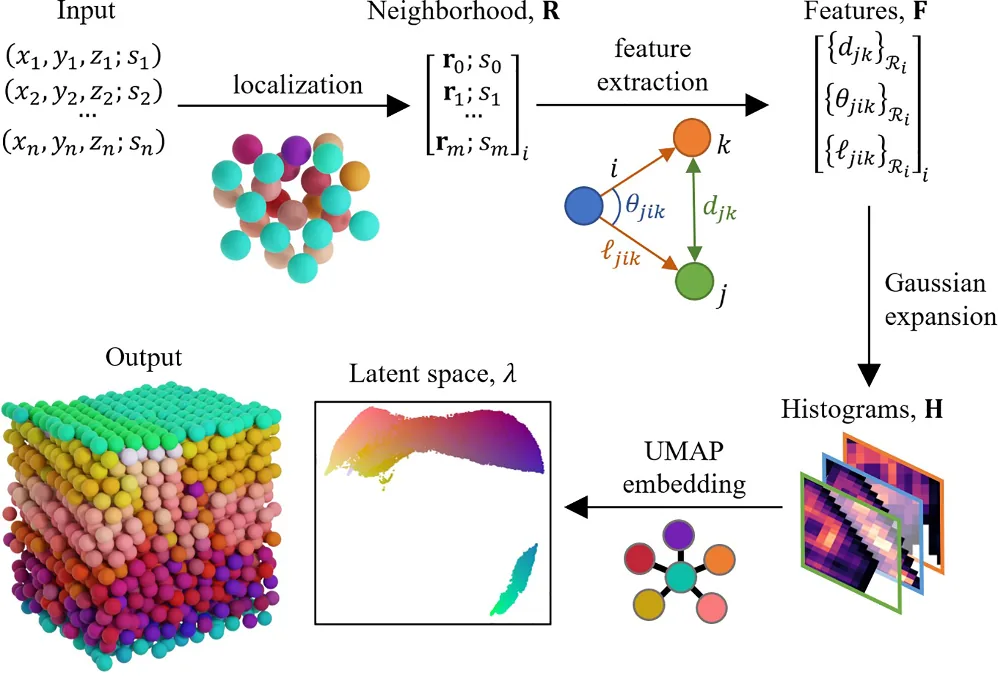

*Fig. 1. Reinhart, Comput. Mater. Sci. **196**, 110511 (2021). [doi.org/10.1016/j.commatsci.2021.110511](https://doi.org/10.1016/j.commatsci.2021.110511)*

The paper turns particle coordinates into local three-body descriptors, expands them into histograms, and embeds them with UMAP.
Its central problem is ours: represent structure without guessing one hand-built order parameter.

This notebook uses a different teaching pipeline.
We render a KDE image, pass it through a pretrained EfficientNet, and keep a 1280-number fingerprint.
We borrow the paper's problem and design criteria, not its descriptor.

Our route is simpler, but less rigorously invariant to viewing direction.
Section 5 checks whether it still places visually similar real aggregates near one another.

# 1. Can we trust the data?

No structural measurement means anything until the system reaches steady state.

A melt dropped into a box from a crude starting configuration spends the first part of its life *relaxing*.
Chains disentangle, domains coarsen, and the energy slides downhill.
Any number computed during that slide describes a system still in motion, not its equilibrium morphology.

So before measuring anything, we run an **equilibration check**.
We watch a few thermodynamic observables against time and confirm they have flattened into a noisy plateau.
That check gates everything in Section 2.

In [9]:
# Load the run log and look at it before plotting.
# Columns are: step, pressure, temperature, potential energy
log = np.loadtxt("block_copolymer.log", skiprows=1)
print(log.shape)

(4999, 4)


Each row is one logged step of the block-copolymer run.
The columns we care about are the potential energy (PE), the temperature (T), and the pressure (P).

These are the standard equilibration observables.
PE tells us whether the system is still finding lower-energy arrangements, T confirms the thermostat is holding, and P reflects how the box is responding.

The time axis is `step * 0.005` in reduced (Lennard-Jones) units, matching the `dt=0.005` integrator timestep from Notebook 01.
Let's plot all three.

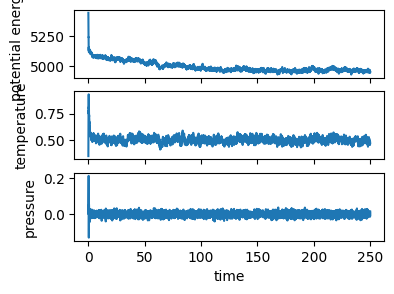

In [10]:
# Check thermodynamic quantities
fig, ax = plt.subplots(3, 1, figsize=(4, 3),sharex=True)
data = np.loadtxt("block_copolymer.log", skiprows=1)
ax[0].plot(data[:, 0]*0.005, data[:, 3])
ax[0].set_ylabel("potential energy")

ax[1].plot(data[:, 0]*0.005, data[:, 2])
ax[1].set_ylabel("temperature")

ax[2].plot(data[:, 0]*0.005, data[:, 1])
ax[2].set_ylabel("pressure")
ax[2].set_xlabel("time")
plt.show()

Read these top to bottom.
There is a steep early ramp where the system relaxes, then a plateau where each curve just jitters around a fixed mean.

The jitter itself is not a problem.
Some fluctuation is required in a finite system at finite temperature.
What matters is whether the *center* of the jitter is still drifting.

Compare the first third of a trace to the last third.
If they differ visibly, keep running.
If they're statistically indistinguishable, you're equilibrated.

But "the curve looks flat" is an eyeball test, and eyeballs are generous.

It raises a sharper question we can actually quantify.
Once we're on the plateau, *how many independent measurements do we really have?*
The answer is almost always far fewer than the number of saved frames, and it's worth knowing by how much.

Here's the catch.
Consecutive MD frames are **correlated**: frame $t{+}1$ is a tiny nudge from frame $t$, not a fresh draw.
So 400 saved frames are nowhere near 400 independent samples.

We quantify that redundancy with the **autocorrelation function**:

$$C(\tau) = \langle \delta O_t\, \delta O_{t+\tau}\rangle / \langle \delta O_t^2\rangle$$

where $\delta O$ is the mean-subtracted observable (`eq`), $\tau$ the lag in frames (`lags`), and $C$ is `acf`.
It starts at $C(0)=1$ and decays as memory of the earlier frame fades.

Summing that decay gives the **integrated correlation time**:

$$\tau_\mathrm{int} = 1 + 2\sum_{\tau\ge 1} C(\tau)$$

Read it as roughly "how far apart must two snapshots be before they're effectively independent."
Divide the sample count by it for the effective sample size, $N_\mathrm{eff} = N / \tau_\mathrm{int}$.

No synthetic stand-in is needed here.
`block_copolymer.gsd` already holds real logged frames from a genuine Langevin run on a fixed step interval, using the same FENE-WCA bond (`k=30, r0=1.5`) as the rest of the campaign.
We compute its actual $R_g^2(t)$ and run the machinery on real data.

In [11]:
# Real fine-grained equilibration series: per-frame Rg^2 of this trajectory,
# computed directly from the production trajectory (same five-step recipe as
# calc_Rg2 in Section 2 -- shown here first because Section 1 needs a fine time
# series before Section 2 introduces the function by name).
trajectory = gsd.hoomd.open('block_copolymer.gsd', mode='r')
N_polymer = 30
signal, t = [], []
for frame in trajectory:
    unwrapped = frame.particles.position + frame.particles.image * frame.configuration.box[0:3]
    polymers = np.split(unwrapped, N_polymer)
    rg_sq_frame = np.mean([np.mean(np.sum((p - p.mean(0))**2, axis=1)) for p in polymers])
    signal.append(rg_sq_frame)
    t.append(frame.configuration.step * 0.005)
signal = np.asarray(signal)
t = np.asarray(t)
# ~1/3 of the trajectory, matching the original transient fraction -- computed
# from length so this survives future NB01 parameter changes (frame count here
# is driven by n_frames/chunk/GSD-write-trigger in Notebook 01, not fixed).
discard = len(signal) // 3
print(f"{len(signal)} frames, t = {t[0]:.1f} to {t[-1]:.1f} (reduced units)")

499 frames, t = 0.5 to 249.5 (reduced units)


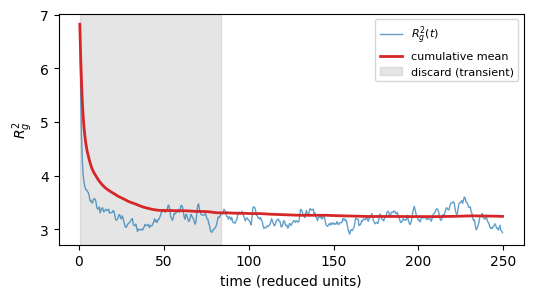

In [12]:
run_mean = np.cumsum(signal) / np.arange(1, len(signal) + 1)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(t, signal, lw=1, alpha=0.7, label='$R_g^2(t)$')
ax.plot(t, run_mean, 'C3', lw=2, label='cumulative mean')
ax.axvspan(t[0], t[discard], color='gray', alpha=0.2, label='discard (transient)')
ax.set_xlabel('time (reduced units)')
ax.set_ylabel('$R_g^2$')
ax.legend(fontsize=8)
plt.show()

$R_g^2$ falls sharply as the initial configuration relaxes and the B beads begin aggregating, then settles into a noisy plateau.
The cumulative mean (red) is dragged down for a long time by that transient.
It only levels off once enough plateau frames outweigh the early relaxing ones.
That is the visual argument for discarding the transient before averaging: every frame in the shaded window biases the estimate low.

Be precise about what `discard = len(signal) // 3` is.
It is a fixed one-third heuristic, not an equilibration onset detected from the data.

In particular, it is not derived from the autocorrelation time computed below.
That calculation runs only on the already-discarded segment, so it tells us how correlated the retained plateau is, not where the plateau begins.

A real onset detector would find that boundary from the signal itself, using a rolling-mean stability test or a change-point method.
We use the fixed fraction because this trajectory's transient finishes well within the first third.
Section 2 slices off the first third for the same reason.
Treat that slice as a heuristic, not a rigorously detected equilibration point.

In [13]:
# Autocorrelation of the equilibrated segment, computed by hand
eq = signal[discard:] - signal[discard:].mean()   # mean-subtract the plateau segment
full = np.correlate(eq, eq, mode='full')           # raw autocorrelation at all lags
acf = full[full.size // 2:]                        # keep non-negative lags
acf = acf / acf[0]                                 # normalize so C(0) = 1
lags = np.arange(acf.size)
print(f'autocorrelation over {acf.size} lags, C(0) = {acf[0]:.2f}')

autocorrelation over 333 lags, C(0) = 1.00


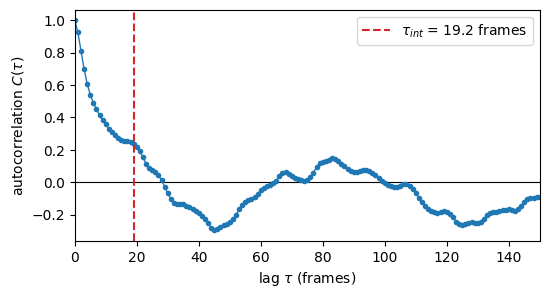

In [14]:
first_neg = np.argmax(acf < 0)
tau_int = 1 + 2 * np.sum(acf[1:first_neg])
fig, ax = plt.subplots(figsize=(6, 3))
ax.axhline(0, c='k', lw=0.8)
ax.plot(lags, acf, 'C0-o', ms=3, lw=1)
ax.axvline(tau_int, c='C3', ls='--', label=f'$\\tau_{{int}}$ = {tau_int:.1f} frames')
ax.set_xlabel('lag $\\tau$ (frames)')
ax.set_ylabel('autocorrelation $C(\\tau)$')
ax.set_xlim(0, 150)
ax.legend()
plt.show()

The autocorrelation starts at 1 and decays to zero over several dozen frames.
A real polymer's shape memory persists far longer than a single logged step.

Summing the positive part, up to the first zero crossing (`first_neg`), gives the integrated time.
Let's turn it into a sample count.

In [15]:
first_neg = np.argmax(acf < 0)          # stop the sum at the first zero crossing
tau_int = 1 + 2 * np.sum(acf[1:first_neg])
N_eff = len(eq) / tau_int
print(f"tau_int = {tau_int:.1f} frames,  N = {len(eq)},  N_eff = {N_eff:.0f}")

tau_int = 19.2 frames,  N = 333,  N_eff = 17


The `tau_int` and `N_eff` printed above are real computed numbers for *this* run.
A different seed shifts them slightly.

A few hundred equilibrated frames collapse to a much smaller number of *effectively independent* samples once divided by the correlation time.
This trajectory's `N_eff` typically lands in the low tens, not the hundreds of raw frames.

That is the honest sample size, and the reason we average over the whole equilibrated tail rather than quoting any single frame.
Report a mean from a correlated trace as if every frame were independent and you will badly underestimate its error bar.

## [Check your understanding]

* Before running anything, predict: if you *include* the transient frames (`signal[:discard]`) in your average instead of discarding them, does the estimated mean come out too high, too low, or unbiased? Why?
* Compute the mean of `signal` two ways: over the full series, and over `signal[discard:]`. Compare them.
* Given `tau_int`, roughly how many *effectively independent* samples does the equilibrated segment hold?

> Including the transient biases the mean high here, since the transient starts above the plateau and decays down into it, and it inflates the scatter as well.
> The two means should differ by more than the plateau's frame-to-frame noise.
> Divide the equilibrated frame count (`len(eq)`, printed above) by `tau_int` to get `N_eff`, typically in the low tens.

# 2. Classical descriptors and the degeneracy problem

Now that we trust the data, what can a hand-computed scalar tell us?
Before reaching for a neural network, ask what the cheapest descriptor already captures.

Notebook 02, Section 4 introduced the **radius of gyration** conceptually, as a per-chain size probe:

$$R_g^2 = \frac{1}{N}\sum_{i=1}^{N}\lVert \mathbf{r}_i - \mathbf{r}_\mathrm{com}\rVert^2$$

Here we recall that definition and, for the first time, build it from scratch.
In code, $\mathbf{r}_i$ is a row of `polymer`, $\mathbf{r}_\mathrm{com}$ is `com`, and $R_g^2$ is `rg_sq`.

It is one number summarizing how spread out a structure's mass is: small for a tight globule, large for an extended coil.

It has real physical pedigree, connecting directly to scattering experiments and to the ideal-vs-real-chain scaling laws from Notebook 01.
This is also the notebook's one from-scratch implementation.
We compute it by hand rather than calling a library, precisely because it's the descriptor whose limits we most need to feel in our fingers.

Read `calc_Rg2` below as a five-step recipe:

1. **Unwrap the periodic boundary.** Add back `image * box` to recover continuous coordinates.
2. **Split** the flat bead array into `N_polymer` chains with `np.split`.
3. **Center** each chain on its own `com`.
4. **Average the squared displacements.** That inner `np.mean(np.sum(diff**2, axis=1))` *is* $R_g^2$ for one chain.
5. **Average** over chains and over frames.

Step 1 is the one people forget.
Skip it and a single chain straddling the box edge looks enormous, poisoning the whole average with a spuriously huge `rg_sq`.

In [16]:
import gsd, gsd.hoomd

In [17]:
def calc_Rg2(trajectory, N_polymer):
    rg_sq_by_frame = []
    time = []
    for frame in trajectory:
        # 1. unwrap the periodic boundary
        unwrapped = frame.particles.position + frame.particles.image * frame.configuration.box[0:3]
        # 2. split the flat bead array into chains
        polymers = np.split(unwrapped, N_polymer)
        rg_sq_this_frame = []
        for polymer in polymers:
            com = np.mean(polymer, axis=0)              # 3. center each chain
            diff = polymer - com
            rg_sq = np.mean(np.sum(diff**2, axis=1))    # 4. average squared displacements
            rg_sq_this_frame.append(rg_sq)
        # 5. average over chains, then store this frame
        rg_sq_by_frame.append(np.mean(rg_sq_this_frame))
        time.append(frame.configuration.step * 0.005)
    return time, rg_sq_by_frame

Run it on the block trajectory first.

In [18]:
N_polymer = 30
trajectory = gsd.hoomd.open('block_copolymer.gsd', mode='r')
time, rg_sq_by_frame = calc_Rg2(trajectory, N_polymer)
print(f'{len(rg_sq_by_frame)} frames, Rg^2 from {rg_sq_by_frame[0]:.1f} down to {rg_sq_by_frame[-1]:.1f}')

499 frames, Rg^2 from 6.8 down to 2.9


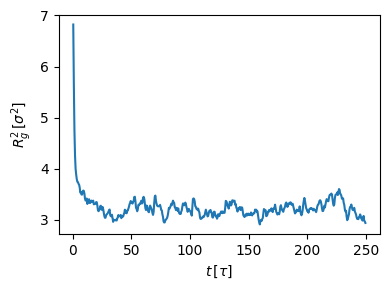

In [19]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(time, rg_sq_by_frame)
ax.set_ylabel(r"$R_g^2\,[\sigma^2]$")
ax.set_xlabel(r"$t\,[\tau]$")
plt.tight_layout()
plt.show()

There is the equilibration signature again.

$R_g^2$ falls sharply from the extended initial configuration, then fluctuates around a lower plateau.
That is why the averaging below slices off the transient before taking a mean.

Now both sequences.

We average the equilibrated tail only, discarding the first third of each trajectory.
The fraction is computed per file, since nothing guarantees the two runs are the same length.

In [20]:
averages = []
for trajectory_file in ['block_copolymer.gsd', 'alternating_polymer.gsd']:
    trajectory = gsd.hoomd.open(trajectory_file, mode='r')
    time, rg_sq_by_frame = calc_Rg2(trajectory, N_polymer)
    rg_sq_by_frame = np.asarray(rg_sq_by_frame)
    discard = len(rg_sq_by_frame) // 3
    averages.append(np.average(rg_sq_by_frame[discard:]))

print(f'discarded the first {discard} of {len(rg_sq_by_frame)} frames from each run')

discarded the first 166 of 499 frames from each run


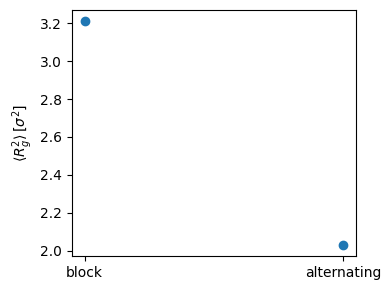

In [21]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.scatter([0, 1], averages)
ax.set_xticks([0, 1])
ax.set_xticklabels(['block', 'alternating'])
ax.set_ylabel(r"$\langle R_g^2\rangle\,[\sigma^2]$")
plt.tight_layout()
plt.show()

Let's print the two numbers.

In [22]:
print(f"block Rg^2 = {averages[0]:.2f},  alternating Rg^2 = {averages[1]:.2f}")

block Rg^2 = 3.21,  alternating Rg^2 = 2.03


## [Check your understanding] Values of Rg

Would you expect per-chain $R_g^2$ to differ between a block and an alternating sequence, and which way?
Think about where the cohesive B beads end up.
Then check the computed averages, and recall from Section 1 how noisy a single short comparison can be.

These two come out different.
The block and alternating trajectories are genuinely independent runs, so this is a real if unremarkable physical result: this particular block sequence is a bit more extended than this particular alternating one.

Don't over-read the specific numbers.
With about 30 chains and a short run, a single comparison is noisy.
Take the *method* from this cell, the `calc_Rg2` recipe and discarding the transient before averaging, not this pair as a general claim about block-versus-alternating architecture.

The real lesson survives either way.
Even when $R_g$ does discriminate two structures, it only reports overall size, never *how* the mass is arranged.

You could add higher moments, such as asphericity or the gyration-tensor eigenvalues, and climb a ladder of ever-more-elaborate hand-crafted measures.
Area-to-volume ratio, genus, contact and cluster statistics: each rung buys a little more discrimination, and we compute several of them in the Day 3 lab.

But every rung is still a human guessing which summary matters.
Statt et al. (2021) found that even this elaborate hand-crafted family resolves only the coarsest morphology categories.
Let's construct the case where the simplest rung goes blind.

*Can two different structures have the same $R_g$?*

Yes, and we don't have to invent a toy example to see it.
`data/exhaustive10/descriptors.csv` catalogs $R_g$, `shape_anisotropy`, and `largest_b_cluster_frac` for all 528 canonical length-10 A/B sequences (seed 1).

Sequences `0010011110` and `0110101101` differ by one B bead.
Their $R_g$ agrees to within about 3%, yet their `shape_anisotropy` differs by more than a factor of ten.
$R_g$ cannot tell them apart; shape can.

Let's load both full 200-chain trajectories from the campaign bundle and see the difference directly.

One naming note.
The $R_g$ in `descriptors.csv` measures each sequence's largest connected B-bead cluster, not a single chain (`calc_Rg2` above) and not the whole 200-chain system.
The code below measures that third quantity, the whole point cloud's $R_g^2$, named `rg2_structure` to keep it distinct from both.

`data/exhaustive10/descriptors.csv` is small and tracked in git.
We verify it's present up front rather than fail deep inside a helper with a cryptic error.

In [23]:
#@title  ⚙️  data_bootstrap — verify data/master64 & data/exhaustive10 artifacts are present. You can ignore this cell. { display-mode: "form" }
#
# A fresh checkout only ships the small derived tables in data/master64/ (tracked in git,
# see data/master64/README.md) -- the large binaries (atlas*.png, _images/, GSD bundle) and
# the full exhaustive10 library are regenerated or fetched separately and are NOT guaranteed
# to be present. Rather than let a missing file surface as a cryptic pandas/joblib traceback
# many cells later, this module checks up front and fails with an actionable message.
#
# This is deliberately a *data*-layer check, not a model one: models/gru_bundle.joblib has
# its own, stricter provenance binding (sha256 of pca.joblib + sequence_z_targets.csv recorded
# inside the bundle, checked at load time -- see notebook 06, "Provenance binding, not just a
# file-exists cache"). That check catches "this trained model doesn't match today's data" and
# is not duplicated here. This module only answers the earlier question: are the required data
# files even on disk, and do the git-tracked ones match what's checked in (data/master64/checksums.json)?

import csv
import hashlib
import json
import os
import tarfile
import urllib.request


def sha256_of_file(path, chunk_size=1 << 20):
    """Hash a file's bytes. Same convention notebook 06 uses to bind gru_bundle.joblib
    to the pca.joblib / sequence_z_targets.csv it was trained against."""
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(chunk_size), b''):
            h.update(chunk)
    return h.hexdigest()


def require_data_artifacts(base_dir, filenames, checksums_path=None, regen_hint=''):
    """Verify each of `filenames` exists under `base_dir`, and -- if `checksums_path` points
    at a JSON {filename: sha256} manifest that has an entry for it -- that its sha256 matches.

    Call this once, right after the relevant `*_DIR` is set, before any of `filenames` is
    read. Raises RuntimeError with every missing/mismatched file listed together (not just
    the first one hit) and a regeneration hint, instead of letting the notebook die on
    whichever read happens to come first.
    """
    checksums = {}
    if checksums_path and os.path.exists(checksums_path):
        with open(checksums_path) as f:
            checksums = json.load(f)

    missing, mismatched = [], []
    for name in filenames:
        path = os.path.join(base_dir, name)
        if not os.path.exists(path):
            missing.append(path)
            continue
        expected = checksums.get(name)
        if expected is not None:
            actual = sha256_of_file(path)
            if actual != expected:
                mismatched.append((path, expected, actual))

    if not missing and not mismatched:
        return

    parts = []
    if missing:
        listed = '\n  '.join(missing)
        parts.append(f'Missing required data artifact(s):\n  {listed}')
    if mismatched:
        listed = '\n  '.join(
            f'{p}\n    expected sha256 {exp[:12]}…, found {act[:12]}… '
            f'(local file does not match data/master64/checksums.json)'
            for p, exp, act in mismatched
        )
        parts.append(f'Data artifact(s) present but do NOT match the checked-in checksums:\n  {listed}')
    if regen_hint:
        parts.append(regen_hint)
    raise RuntimeError('\n\n'.join(parts))


# ── Bundle fetch shim (data/_bundles/*.tar.gz) ──────────────────────────────
#
# `data/_bundles/` holds gzip-tar archives packaging the subset of `data/` a
# fresh checkout doesn't ship (large binaries: images, GSDs, the exhaustive10
# library). Each archive's relative paths match their layout under `data/`
# exactly (e.g. `master64/pca.joblib`, `kg10-gsd-bundle/gsd/<seq>_seed1.gsd`), so
# extracting one directly into `data_dir` reproduces the paths every notebook
# already expects -- no notebook-side path changes needed once a bundle is
# fetched. See `data/_bundles/manifest.json` for the authoritative sha256/size
# of every archive; this module's `ensure_bundle` reads that same file.
#
# Hosted on Zenodo, concept DOI 10.5281/zenodo.21382941, which always resolves to the
# latest version. ZENODO_RECORD above pins a specific version record on purpose, so a
# checkout keeps fetching the exact archives it was tested against: currently v2
# (record 21856114), which adds the random-walk-init arm to v1's (21382942) lattice-init
# data. Zenodo carries every prior version's files forward, so the v1 archive names keep
# resolving against the newer record.
# Wired up and live: within Day 1, notebook 02 calls `ensure_bundle('core')` and 03
# calls `ensure_bundle('core')` + `ensure_bundle('full_images')` before the cells that
# read the large binaries.
#
# Kept identical to day2/day3's copies of this shim (same URLs) -- duplicated per-day
# rather than cross-imported, matching this repo's existing convention of a
# self-contained data_bootstrap.py per day. Only the day-specific loaders and helpers
# differ between the three copies (`fetch_gsd_for_sequence` here, the exhaustive10 .npz
# loaders in day2, `reconcile_bundle_models()` in day3).

ZENODO_RECORD = 'https://zenodo.org/api/records/21856114/files'

BUNDLE_URLS = {
    'core': f'{ZENODO_RECORD}/core.tar.gz/content',
    'full_images': f'{ZENODO_RECORD}/full_images.tar.gz/content',
    'gsd_shard_01': f'{ZENODO_RECORD}/gsd_shard_01.tar.gz/content',
    'gsd_shard_02': f'{ZENODO_RECORD}/gsd_shard_02.tar.gz/content',
    'gsd_shard_03': f'{ZENODO_RECORD}/gsd_shard_03.tar.gz/content',
    'gsd_shard_04': f'{ZENODO_RECORD}/gsd_shard_04.tar.gz/content',
    'gsd_shard_05': f'{ZENODO_RECORD}/gsd_shard_05.tar.gz/content',
    'gsd_shard_06': f'{ZENODO_RECORD}/gsd_shard_06.tar.gz/content',
    'gsd_shard_07': f'{ZENODO_RECORD}/gsd_shard_07.tar.gz/content',
    'gsd_shard_08': f'{ZENODO_RECORD}/gsd_shard_08.tar.gz/content',
    'gsd_shard_09': f'{ZENODO_RECORD}/gsd_shard_09.tar.gz/content',
    'gsd_shard_10': f'{ZENODO_RECORD}/gsd_shard_10.tar.gz/content',
    'gsd_shard_11': f'{ZENODO_RECORD}/gsd_shard_11.tar.gz/content',
    'gsd_shard_12': f'{ZENODO_RECORD}/gsd_shard_12.tar.gz/content',
    'gsd_shard_13': f'{ZENODO_RECORD}/gsd_shard_13.tar.gz/content',
    'gsd_shard_14': f'{ZENODO_RECORD}/gsd_shard_14.tar.gz/content',
    'gsd_shard_15': f'{ZENODO_RECORD}/gsd_shard_15.tar.gz/content',
    'gsd_shard_16': f'{ZENODO_RECORD}/gsd_shard_16.tar.gz/content',
    'rwinit_core': f'{ZENODO_RECORD}/rwinit_core.tar.gz/content',
    'rwinit_gsd_shard_01': f'{ZENODO_RECORD}/rwinit_gsd_shard_01.tar.gz/content',
    'rwinit_gsd_shard_02': f'{ZENODO_RECORD}/rwinit_gsd_shard_02.tar.gz/content',
    'rwinit_gsd_shard_03': f'{ZENODO_RECORD}/rwinit_gsd_shard_03.tar.gz/content',
    'rwinit_gsd_shard_04': f'{ZENODO_RECORD}/rwinit_gsd_shard_04.tar.gz/content',
    'rwinit_gsd_shard_05': f'{ZENODO_RECORD}/rwinit_gsd_shard_05.tar.gz/content',
    'rwinit_gsd_shard_06': f'{ZENODO_RECORD}/rwinit_gsd_shard_06.tar.gz/content',
    'rwinit_gsd_shard_07': f'{ZENODO_RECORD}/rwinit_gsd_shard_07.tar.gz/content',
    'rwinit_gsd_shard_08': f'{ZENODO_RECORD}/rwinit_gsd_shard_08.tar.gz/content',
    'rwinit_gsd_shard_09': f'{ZENODO_RECORD}/rwinit_gsd_shard_09.tar.gz/content',
    'rwinit_gsd_shard_10': f'{ZENODO_RECORD}/rwinit_gsd_shard_10.tar.gz/content',
    'rwinit_gsd_shard_11': f'{ZENODO_RECORD}/rwinit_gsd_shard_11.tar.gz/content',
    'rwinit_gsd_shard_12': f'{ZENODO_RECORD}/rwinit_gsd_shard_12.tar.gz/content',
    'rwinit_gsd_shard_13': f'{ZENODO_RECORD}/rwinit_gsd_shard_13.tar.gz/content',
    'rwinit_gsd_shard_14': f'{ZENODO_RECORD}/rwinit_gsd_shard_14.tar.gz/content',
    'rwinit_gsd_shard_15': f'{ZENODO_RECORD}/rwinit_gsd_shard_15.tar.gz/content',
    'rwinit_gsd_shard_16': f'{ZENODO_RECORD}/rwinit_gsd_shard_16.tar.gz/content',
    'rwinit_images': f'{ZENODO_RECORD}/rwinit_images.tar.gz/content',
}


# Embedded copy of data/_bundles/manifest.json (sha256 + size only -- the two fields
# ensure_bundle verifies). The manifest normally ships in the repo, but a Colab student
# opens a bare .ipynb with no repo around it, so a repo-only manifest would make every
# ensure_bundle() call fail before it ever reached Zenodo. The on-disk file still wins
# when present (instructors regenerating bundles); this is the fallback.
EMBEDDED_MANIFEST = {
    "core.tar.gz": {
        "sha256": "aa8e566e323d83a3cf5bd9f8d66af97597176bfa556497536a2313d9257a86e8",
        "size_bytes": 75795762
    },
    "full_images.tar.gz": {
        "sha256": "f5a3be425507b54446b6b8b432432e612637a26105cacd94ba04f46f9fcd9f98",
        "size_bytes": 85260688
    },
    "gsd_shard_01.tar.gz": {
        "sha256": "5ffe93ba71d42eed5abeedcc6e4dd9e0bc8d160e3d2f134cea06285b9781d590",
        "size_bytes": 54428843
    },
    "gsd_shard_02.tar.gz": {
        "sha256": "541573a1d8176f89f4f838698bee261a24818c93967b0c969e8d295ba87805eb",
        "size_bytes": 54515060
    },
    "gsd_shard_03.tar.gz": {
        "sha256": "5fd7ed9efce62468b73e633b3dd56de13ca5d5e83c87222b5d0f30eab3cd874d",
        "size_bytes": 54500993
    },
    "gsd_shard_04.tar.gz": {
        "sha256": "7c2b102d648d918bb5f702137c925533c32c22070d5a20075b536f795251524c",
        "size_bytes": 54501617
    },
    "gsd_shard_05.tar.gz": {
        "sha256": "f8da9b7c5e515e5a61b6b91d390a65a95b85aab48a6b31c6a2f5bb786306e1ee",
        "size_bytes": 54486771
    },
    "gsd_shard_06.tar.gz": {
        "sha256": "40d94a51cf1c4e59e06998e438b40a67ee52f7447e4e8089e6c1ba3efe707e92",
        "size_bytes": 54503309
    },
    "gsd_shard_07.tar.gz": {
        "sha256": "3a1a633d093e8df54062868bca408b2ea81d3121b6e18e151fabd620c9908227",
        "size_bytes": 54545175
    },
    "gsd_shard_08.tar.gz": {
        "sha256": "6edd4e9b39081c82847da3e8f5c048ba07b774513514bb293d8fc43c5f59fe5c",
        "size_bytes": 54553660
    },
    "gsd_shard_09.tar.gz": {
        "sha256": "ddebef1f8420db4e1646013640450f06c50883cc8220e6fe47847dbc816bab48",
        "size_bytes": 54529750
    },
    "gsd_shard_10.tar.gz": {
        "sha256": "8f92a0c7261217e282f16370b1483ab72c7627d452369a302d4a1cb553fd2101",
        "size_bytes": 54576422
    },
    "gsd_shard_11.tar.gz": {
        "sha256": "b4f713683ce4c9a9c7338a973162c33e26fae4abd3198ce51a232d41ab7d8213",
        "size_bytes": 54614646
    },
    "gsd_shard_12.tar.gz": {
        "sha256": "c6d9199bb584dec3dab80518ce52e591d90dcbd55d4565a17bfd899cec1cde90",
        "size_bytes": 54558926
    },
    "gsd_shard_13.tar.gz": {
        "sha256": "e40332193347a5532fc560189608b46617fc277333be14ae6a1a73b4b619ea27",
        "size_bytes": 54515392
    },
    "gsd_shard_14.tar.gz": {
        "sha256": "cd88ff742f800ba576088cb680d0d61dd7c9c63090a77c25deeddf54d728f748",
        "size_bytes": 54556976
    },
    "gsd_shard_15.tar.gz": {
        "sha256": "d4eea2c8040774d777ac384b55c5a8e473e413619c8b799690121986dcce0c61",
        "size_bytes": 54553791
    },
    "gsd_shard_16.tar.gz": {
        "sha256": "403bf562e8325f34d4b04dff699d3cc35a9b4e7dda231e01a5fdb836a9b788d1",
        "size_bytes": 54546362
    },
    "rwinit_core.tar.gz": {
        "sha256": "11cf1dc26ee026894c3be5e845d3999c1f92d43db05b2cd6eeaae92d319f1d34",
        "size_bytes": 7205225
    },
    "rwinit_gsd_shard_01.tar.gz": {
        "sha256": "064e6bd3fa80355f869f0bc29709c9df7ee5957c23e75d0e1507f405de3f7b55",
        "size_bytes": 57106441
    },
    "rwinit_gsd_shard_02.tar.gz": {
        "sha256": "41797e4e0ca818f6f6cee27eef92eecd41fa4bd0bd9d005578feae96c91bb9ac",
        "size_bytes": 57129517
    },
    "rwinit_gsd_shard_03.tar.gz": {
        "sha256": "d78bcb538e3fce2e05cf2dc2a835fd38f05a4073865e67398bec873bfd9941a5",
        "size_bytes": 57072047
    },
    "rwinit_gsd_shard_04.tar.gz": {
        "sha256": "23c24f3dbc2df1d9cdaba442dc88c6beb4c023285ee058cbf4adcaeb8964e603",
        "size_bytes": 57081717
    },
    "rwinit_gsd_shard_05.tar.gz": {
        "sha256": "2dae4ba886506429b40f82896be904a756b3f4bbb0b817792cdd7fb64e54820f",
        "size_bytes": 57089702
    },
    "rwinit_gsd_shard_06.tar.gz": {
        "sha256": "cf175506cbce294a5204abf811db5ca5f74c21d90af1516a30d08e6c188b53e3",
        "size_bytes": 57098922
    },
    "rwinit_gsd_shard_07.tar.gz": {
        "sha256": "d19cab8e719aa1fe4167a7982c3fa9f8acadb776711eb4aa2dba2840fcdd27d0",
        "size_bytes": 57116603
    },
    "rwinit_gsd_shard_08.tar.gz": {
        "sha256": "55ac119a7e3159659151abe48811389568030095af779b9adcbd5d2039f7897a",
        "size_bytes": 57066241
    },
    "rwinit_gsd_shard_09.tar.gz": {
        "sha256": "750a92ae6bf8fe2cf9fe84614c980f03ea9a216253a4e3fd501d8879ec69fad7",
        "size_bytes": 57096549
    },
    "rwinit_gsd_shard_10.tar.gz": {
        "sha256": "4bb7b54dde96fb561b9ed961882a4310f6de42536cd80d4f7060cef604b116e7",
        "size_bytes": 57082391
    },
    "rwinit_gsd_shard_11.tar.gz": {
        "sha256": "8c284243824ca2b8630b306ea5d44c9fe64c63638a361b6c7e60d4894d156264",
        "size_bytes": 57056742
    },
    "rwinit_gsd_shard_12.tar.gz": {
        "sha256": "251b86d2a278b5f10bbb192dc4c0deb6f965cb9ab47068a9520cf6bcb88a8035",
        "size_bytes": 57070629
    },
    "rwinit_gsd_shard_13.tar.gz": {
        "sha256": "e6e2d6771e8692774e71cf888d189d8c67b511e42b76434d13bf6088f88e4467",
        "size_bytes": 57086857
    },
    "rwinit_gsd_shard_14.tar.gz": {
        "sha256": "08285cd063243b96d05449b80356f83e16fd50c2a5b9913f59f6204d72423479",
        "size_bytes": 57101498
    },
    "rwinit_gsd_shard_15.tar.gz": {
        "sha256": "b700f555dbf7f59bc46bb6f41a6745a7397c5094a52a53f1b46969ab333a27ea",
        "size_bytes": 57105780
    },
    "rwinit_gsd_shard_16.tar.gz": {
        "sha256": "1a0a6519f41984aead7405bc927e1159d02f9adff42b8076a52846e174a20542",
        "size_bytes": 57058599
    },
    "rwinit_images.tar.gz": {
        "sha256": "88919f2fcc542f6681fd65f82c80c40f346ef5b911089d09496d58a817ad247d",
        "size_bytes": 290556878
    },
}


def ensure_bundle(name, data_dir=None, manifest_path=None):
    """Download-if-absent + sha256-verify + extract a named bundle archive into `data_dir`.

    `name` is a key of `BUNDLE_URLS` (e.g. `'core'`, `'gsd_shard_03'`). Idempotent: if
    `data_dir/_bundles/<name>.tar.gz` already exists on disk AND matches the sha256
    recorded in the manifest, it is reused rather than re-downloaded; the archive is
    always re-verified against the manifest before extraction, so a corrupt or partial
    local copy is caught rather than silently extracted.

    `data_dir` defaults to `'../data'`, matching the relative path every notebook in
    this repo already uses for `MASTER_DIR`/`EXHAUSTIVE_DIR`/`GSD_DIR`. `manifest_path`
    defaults to `<data_dir>/_bundles/manifest.json`.
    """
    if data_dir is None:
        data_dir = '../data'
    if manifest_path is None:
        manifest_path = os.path.join(data_dir, '_bundles', 'manifest.json')

    if name not in BUNDLE_URLS:
        raise RuntimeError(
            f"Unknown bundle {name!r}. Known bundles: {sorted(BUNDLE_URLS)}."
        )
    url = BUNDLE_URLS[name]
    if url is None:
        raise RuntimeError(
            f"Bundle {name!r} is not hosted yet (BUNDLE_URLS[{name!r}] is None in "
            f"data_bootstrap.py). Fill in its URL once hosting exists. Until then, "
            f"the data this bundle would provide (see its 'contents_summary' in "
            f"data/_bundles/manifest.json) must already be present on disk for any "
            f"notebook that needs it."
        )

    if os.path.exists(manifest_path):
        with open(manifest_path) as f:
            manifest = json.load(f)
    else:
        manifest = EMBEDDED_MANIFEST

    archive_filename = f'{name}.tar.gz'
    if archive_filename not in manifest:
        raise RuntimeError(
            f"{archive_filename!r} has no entry in {manifest_path}. Known archives: "
            f"{sorted(manifest)}."
        )
    entry = manifest[archive_filename]
    expected_sha256 = entry['sha256']
    expected_size = entry['size_bytes']

    bundles_dir = os.path.join(data_dir, '_bundles')
    os.makedirs(bundles_dir, exist_ok=True)
    archive_path = os.path.join(bundles_dir, archive_filename)

    def _verified():
        return (
            os.path.exists(archive_path)
            and os.path.getsize(archive_path) == expected_size
            and sha256_of_file(archive_path) == expected_sha256
        )

    if not _verified():
        print(f'Downloading {archive_filename} from {url} ...')
        urllib.request.urlretrieve(url, archive_path)
        if not _verified():
            raise RuntimeError(
                f"Downloaded {archive_path} does not match the manifest (expected "
                f"sha256 {expected_sha256[:12]}..., size {expected_size} bytes). The "
                f"download may be corrupt or the hosted file may not match "
                f"{manifest_path} -- delete {archive_path} and retry, or re-check the "
                f"manifest."
            )

    print(f'Extracting {archive_filename} into {data_dir} ...')
    with tarfile.open(archive_path, 'r:gz') as tf:
        tf.extractall(data_dir)
    print(f'{name!r} bundle ready under {data_dir}.')


# The two initialization arms of the campaign. Both cover the same 528 canonical
# sequences x 3 seeds, but they are separate simulation runs shipped as separate archives,
# so each needs its own shard index, bundle prefix, and extraction root.
#
# `grid` is the default and the arm every notebook uses unless it asks otherwise: chains
# are laid out on a lattice before equilibration. `rwinit` re-runs the same sequences from
# random-walk initial configurations, which is the control showing that some blocky-sequence
# morphologies in the grid arm are artifacts of that initial lattice rather than
# sequence-driven structure.
#
# The two shard maps are NOT interchangeable. Both partition 528 sequences into 16 shards
# of 33, but 480 of the 528 sequences land on a *different* shard number between the arms
# (BUNDLE_V2.md's claim that "the same partition" was used describes the scheme, not the
# assignment). Looking a sequence up in the wrong arm's index fetches a shard that does not
# contain it.
GSD_ARMS = {
    'grid': {
        'csv': 'sequence_to_shard.csv',
        'shard_prefix': 'gsd_shard',
        'root': 'kg10-gsd-bundle',
    },
    'rwinit': {
        'csv': 'sequence_to_shard_rwinit.csv',
        'shard_prefix': 'rwinit_gsd_shard',
        'root': 'kg10-gsd-bundle-rwinit',
    },
}


def _ensure_shard_table(csv_name, data_dir):
    """Return the path to a sequence->shard table, fetching it from Zenodo if absent.

    The tables are git-tracked, which is enough for an instructor checkout but not for
    Colab: the badge loads only the .ipynb into a bare VM and the setup cell deliberately
    does NOT clone the repo, so nothing under `data/_bundles/` exists there and
    `core.tar.gz` does not carry these tables either. Both are published as standalone
    files on the Zenodo record alongside the archives, so fetch on demand -- the same
    shape as `ensure_bundle` falling back to `EMBEDDED_MANIFEST` when the on-disk
    manifest is missing.
    """
    path = os.path.join(data_dir, '_bundles', csv_name)
    if os.path.exists(path):
        return path
    url = f'{ZENODO_RECORD}/{csv_name}/content'
    os.makedirs(os.path.dirname(path), exist_ok=True)
    print(f'Fetching {csv_name} from {url} ...')
    try:
        urllib.request.urlretrieve(url, path)
    except Exception as exc:
        if os.path.exists(path):
            os.remove(path)                     # never leave a truncated table behind
        raise RuntimeError(
            f"could not fetch {csv_name} from {url} ({exc}). It maps each of the 528 "
            f"canonical sequences to its GSD shard. Check network access, or copy the file "
            f"into {os.path.join(data_dir, '_bundles')} from a repo checkout."
        ) from exc
    return path


def fetch_gsd_for_sequence(sequence, seed=1, data_dir=None, init='grid'):
    """Fetch (if needed) whichever GSD shard holds `sequence`'s trajectory and return the
    path to its `<sequence>_seed<seed>.gsd` file.

    `core` only ships a curated 67-sequence subset of the full 528-sequence GSD library
    (namely master64's 64 canonical sequences + the 3 named ones notebook 03 loads
    directly). For an arbitrary sequence outside that set -- e.g. notebook 03's
    "[Check your understanding]" invitation to fingerprint any sequence from
    `data/kg10-gsd-bundle` -- this looks it up in the arm's sequence->shard table and
    fetches just that one ~55 MB shard rather than the full ~900 MB GSD library.

    `init` selects the initialization arm: `'grid'` (default, unchanged behaviour) or
    `'rwinit'` for the random-walk-init control. The two arms live in separate archives and
    extract to separate directories, so both can sit on disk at once and a notebook can
    compare the same sequence under either initialization.
    """
    if data_dir is None:
        data_dir = '../data'
    if init not in GSD_ARMS:
        raise ValueError(f"init must be one of {sorted(GSD_ARMS)}, got {init!r}")
    arm = GSD_ARMS[init]

    # Check the arm is wired up before blaming the user's checkout. An arm needs both its
    # Zenodo URLs (BUNDLE_URLS) and its shard table on disk, and both land together when
    # tools/apply_rwinit_v2.py runs after the corresponding record is published. Reporting
    # "file missing, go pull" for an arm that was never wired sends people to re-clone a
    # repo that was already up to date.
    if f"{arm['shard_prefix']}_01" not in BUNDLE_URLS:
        raise RuntimeError(
            f"the {init!r} initialization arm isn't available in this checkout yet.\n"
            f"Nothing is wrong with your branch -- the arm's archives are not published "
            f"yet, so nothing references them.\n"
            f"It becomes available once the Zenodo record carrying the {init!r} archives is "
            f"published and tools/apply_rwinit_v2.py has been run against that record id "
            f"(which adds the download URLs and moves {arm['csv']} into data/_bundles/).\n"
            f"Until then, use init='grid' (the default)."
        )

    csv_path = _ensure_shard_table(arm['csv'], data_dir)
    with open(csv_path, newline='') as f:
        shard_by_seq = {row['sequence']: int(row['shard_number']) for row in csv.DictReader(f)}

    if sequence not in shard_by_seq:
        raise RuntimeError(
            f"{sequence!r} is not one of the 528 canonical sequences in "
            f"data/_bundles/{arm['csv']}. Canonical sequences collapse "
            f"reversal-symmetric duplicates -- try the reverse of your sequence, or "
            f"check `descriptors.csv` for the canonical spelling."
        )
    shard_name = f"{arm['shard_prefix']}_{shard_by_seq[sequence]:02d}"
    ensure_bundle(shard_name, data_dir=data_dir)
    gsd_path = os.path.join(data_dir, arm['root'], 'gsd', f'{sequence}_seed{seed}.gsd')
    if not os.path.exists(gsd_path):
        raise RuntimeError(
            f"Fetched {shard_name} but {gsd_path} still isn't there -- seed {seed} may not "
            f"exist for this sequence (each sequence has seeds 1-3)."
        )
    return gsd_path

In [24]:
import os

In [25]:
import pandas as pd

In [26]:
EXHAUSTIVE_DIR = '../data/exhaustive10'  # fixed instructor-side path, not CDSE_DATA_DIR

# The 3 named seed-1 GSDs this notebook loads directly (below, and in the KDE-sweep and
# filter-bank sections) are instructor-side binaries, not tracked in git -- fetch them
# from Zenodo if not already present (idempotent).
ensure_bundle('core')

# `core` only ships a curated subset of exhaustive10/_images (the sequences master64/other
# notebooks need). Section 4's validation below checks a fixed list of 6 sequences that
# isn't a subset of that curation (e.g. '0011100011'), so fetch the full image library too.
ensure_bundle('full_images')

require_data_artifacts(
    EXHAUSTIVE_DIR,
    ['descriptors.csv'],
    regen_hint=(
        'data/exhaustive10/descriptors.csv is small and tracked in git -- if missing, pull the '
        'latest data/exhaustive10/ from git or regenerate via campaign/postprocess.py.'
    ),
)

Extracting core.tar.gz into ../data ...


/var/folders/gp/17x29r6s3l7dzdvpf785tzw40000gn/T/ipykernel_79055/3768046310.py:279: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(data_dir)


'core' bundle ready under ../data.
Extracting full_images.tar.gz into ../data ...


'full_images' bundle ready under ../data.


In [27]:
_desc = pd.read_csv(os.path.join(EXHAUSTIVE_DIR, 'descriptors.csv'), dtype={'sequence': str})
_desc['sequence'] = _desc['sequence'].str.zfill(10)
_pair = ['0010011110', '0110101101']
_desc_pair = _desc[_desc.sequence.isin(_pair) & (_desc.seed == 1)].set_index('sequence')
print(_desc_pair[['rg', 'shape_anisotropy', 'largest_b_cluster_frac']])

                  rg  shape_anisotropy  largest_b_cluster_frac
sequence                                                      
0010011110  9.385996          0.806104                  0.4590
0110101101  9.165978          0.066965                  0.9925


In [28]:
def rg2_structure(pos):
    # R_g^2 for the WHOLE 200-chain point cloud (every bead, not one chain and
    # not just the largest B-cluster): mean squared distance to its own
    # centroid. Same formula as calc_Rg2's inner step, applied to the full
    # structure instead of one chain.
    return np.mean(np.sum((pos - pos.mean(0))**2, axis=1))

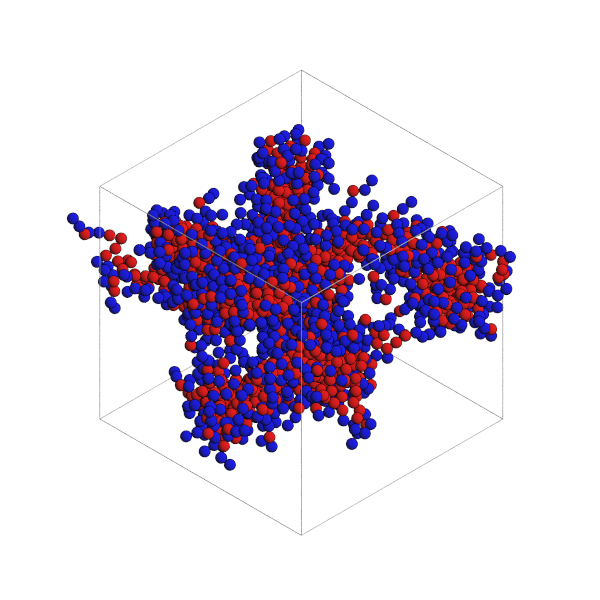

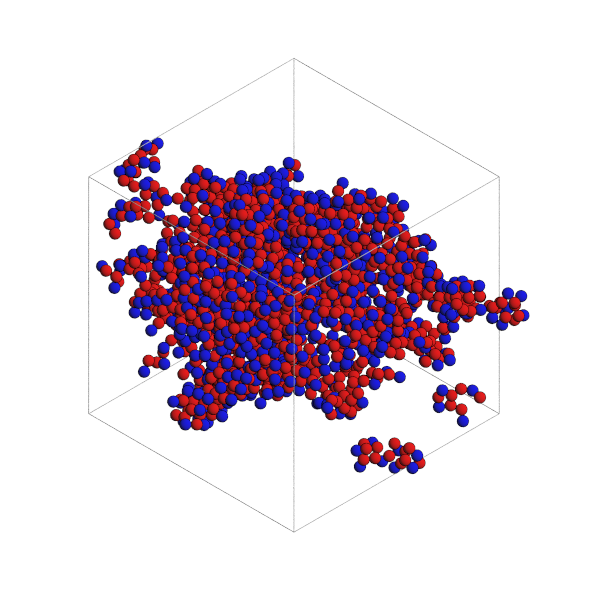

In [29]:
structures = {}
for seq in _pair:
    traj = load_gsd(f'../data/kg10-gsd-bundle/gsd/{seq}_seed1.gsd')
    frame = traj[-1]                    # final (equilibrated) production frame
    pos = unwrap(frame) - unwrap(frame).mean(0)
    structures[seq] = {'pos': pos, 'typeid': frame['typeid'], 'rg2_structure': rg2_structure(pos), 'box': frame['box']}
    render_pretty(frame)

In [30]:
for seq in _pair:
    print(f"{seq}: whole-structure Rg^2 = {structures[seq]['rg2_structure']:.2f}")
assert np.isclose(structures[_pair[0]]['rg2_structure'], structures[_pair[1]]['rg2_structure'], rtol=0.02)   # matched to ~2%

0010011110: whole-structure Rg^2 = 99.49
0110101101: whole-structure Rg^2 = 99.03


Nearly identical whole-structure $R_g^2$, as advertised.

Now render both as density images so the *shape* difference is visible.
We project each into its own principal-axis frame, using the gyration tensor's eigenvectors, so the elongated direction lines up with the horizontal axis for both, whatever way each happens to sit in its simulation box.

In [31]:
from scipy.ndimage import gaussian_filter

In [32]:
def kde_image_pa(pos, extent=20, img_size=224, kde_sigma=2.0):
    # Project onto the top-2 gyration-tensor eigenvectors, then KDE.
    G = np.einsum('ni,nj->ij', pos, pos) / len(pos)
    evals, evecs = np.linalg.eigh(G)
    evecs = evecs[:, np.argsort(evals)[::-1]]     # axis 0 = longest
    pts2d = (pos @ evecs)[:, [0, 1]]
    H, _, _ = np.histogram2d(pts2d[:, 0], pts2d[:, 1], bins=img_size,
                              range=[[-extent, extent], [-extent, extent]])
    H = gaussian_filter(H, sigma=kde_sigma)
    return H / H.max() if H.max() > 0 else H

/var/folders/gp/17x29r6s3l7dzdvpf785tzw40000gn/T/ipykernel_79055/810200763.py:6: RuntimeWarning: divide by zero encountered in matmul
  pts2d = (pos @ evecs)[:, [0, 1]]
/var/folders/gp/17x29r6s3l7dzdvpf785tzw40000gn/T/ipykernel_79055/810200763.py:6: RuntimeWarning: overflow encountered in matmul
  pts2d = (pos @ evecs)[:, [0, 1]]
/var/folders/gp/17x29r6s3l7dzdvpf785tzw40000gn/T/ipykernel_79055/810200763.py:6: RuntimeWarning: invalid value encountered in matmul
  pts2d = (pos @ evecs)[:, [0, 1]]


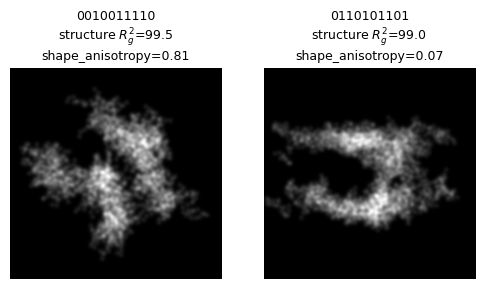

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3.2))
for ax, seq in zip(axes, _pair):
    img = kde_image_pa(structures[seq]['pos'])
    ax.imshow(img.T, origin='lower', cmap='gray')
    sa = _desc_pair.loc[seq, 'shape_anisotropy']
    ax.set_title(f'{seq}\nstructure $R_g^2$={structures[seq]["rg2_structure"]:.1f}\nshape_anisotropy={sa:.2f}', fontsize=9)
    ax.axis('off')
plt.show()

Same whole-structure $R_g^2$, visibly different shape.
`0010011110`, with the higher `shape_anisotropy`, reads as more elongated along its long axis, while `0110101101` reads rounder and more compact.

$R_g$ alone cannot see this.
It collapsed two structurally distinct aggregates onto the same number.

`shape_anisotropy` recovers *some* of what $R_g$ threw away, but it's still one more scalar answering one more question, "how elongated?"
It can't answer "where are the domain boundaries?" or "how many separate clusters?" the way an image can.

That is the central tension of representation design, and it runs through the rest of the course.

We want something compact enough to compute and compare at scale, yet complete enough to keep distinct structures distinct.
Hand-crafted scalars sit at the compact-but-incomplete end.
A raw coordinate list sits at the complete-but-useless end: complete, yet not invariant and impossible to compare across structures of different size.

So what *should* a good representation keep, and what can it safely throw away?
That's Section 3.

## [Check your understanding]

* Predict which of the diblock or alternating chain *should* have the larger $R_g^2$ in general, and say why in one sentence. Think about where the cohesive B beads end up. Then check `averages` here to see whether it holds up.
* Pick a different close-$R_g$ pair from `descriptors.csv` (filter on `seed == 1`, sort by `rg`) and check whether their `shape_anisotropy` also differs. Does the degeneracy problem hold up generally, or was `0010011110`/`0110101101` a special case?

> Any two sequences with matched $R_g$ but different `shape_anisotropy` prove the point: $R_g$ cannot be inverted back to a morphology.

# 3. What makes a good representation

A good structural descriptor should be **invariant** to changes that don't change the physics, and **complete** enough to still tell different structures apart.

The physics doesn't care where the box sits (translation), which way it's oriented (rotation), or which identical bead we happened to label "particle 7" (permutation of identical particles).

A descriptor that changes when *only* those change is reporting bookkeeping, not structure.

Worse, it forces any downstream model to waste capacity learning to undo an artifact we could have removed for free.
Building the right invariances into the representation is doing the model's homework for it.

$R_g$ passes all three tests at no cost.
It is built from distances to the center of mass, so shifting, rotating, or relabeling the beads leaves it untouched.
A raw coordinate list passes none of them, since every one of those operations rewrites the array.

Let's watch $R_g^2$ survive each transformation while the raw coordinates change underneath it.
We use one real chain, 10 beads sliced out of the `0010011110` structure from Section 2, rather than a synthetic point cloud.

In [34]:
rng = np.random.default_rng(2)
pts = structures['0010011110']['pos'][:10, :2]   # one real chain's beads (xy projection)

def rg2(p):
    return np.mean(np.sum((p - p.mean(0))**2, axis=1))

print(f"baseline   Rg^2 = {rg2(pts):.3f}")

baseline   Rg^2 = 1.160


In [35]:
shift = np.array([3.0, 1.5])
pts_t = pts + shift
print("coords changed:", not np.allclose(pts, pts_t))   # the raw array is different...
print(f"translated Rg^2 = {rg2(pts_t):.3f}")            # ...but Rg^2 is not

coords changed: True
translated Rg^2 = 1.160


In [36]:
ang = np.deg2rad(50)
Rot = np.array([[np.cos(ang), -np.sin(ang)],
                [np.sin(ang),  np.cos(ang)]])
pts_r = (Rot @ pts.T).T
print(f"rotated    Rg^2 = {rg2(pts_r):.3f}")

rotated    Rg^2 = 1.160


In [37]:
_all_pts = np.vstack([pts, pts_t, pts_r])
_pad = 1.0
_xlim = (_all_pts[:, 0].min() - _pad, _all_pts[:, 0].max() + _pad)
_ylim = (_all_pts[:, 1].min() - _pad, _all_pts[:, 1].max() + _pad)
print(f'plotting {len(pts)} beads across {len(_all_pts)//len(pts)} panels, x range {_xlim[0]:.1f} to {_xlim[1]:.1f}')

plotting 10 beads across 3 panels, x range -4.3 to 6.2


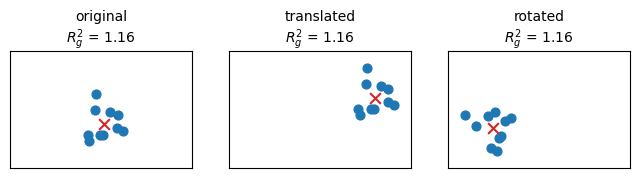

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(8, 2.9))
for ax, p, name in [(axes[0], pts, 'original'), (axes[1], pts_t, 'translated'),
                    (axes[2], pts_r, 'rotated')]:
    ax.scatter(p[:, 0], p[:, 1], s=40)
    ax.scatter(*p.mean(0), marker='x', c='C3', s=60)
    ax.set_title(f'{name}\n$R_g^2$ = {rg2(p):.2f}', fontsize=10)
    ax.set_aspect('equal')
    ax.set_xlim(*_xlim); ax.set_ylim(*_ylim)
    ax.set_xticks([]); ax.set_yticks([])
plt.show()

In [39]:
perm = rng.permutation(len(pts))           # relabel the (identical) beads
pts_p = pts[perm]
print(f"permuted   Rg^2 = {rg2(pts_p):.3f}")
print("all four equal:", np.allclose([rg2(pts_t), rg2(pts_r), rg2(pts_p)], rg2(pts)))

permuted   Rg^2 = 1.160
all four equal: True


All four numbers are identical.
Translation, rotation, and permutation each leave $R_g^2$ exactly where it was, even though the raw coordinate array changed every single time.

So $R_g$ has precisely the invariances we want: it reports structure, not bookkeeping.
What it lacks, as Section 2 showed, is completeness.

Notice *why* the invariances came for free.
$R_g$ is built from distances to the center of mass, and distances are the natural invariant quantity.
Any descriptor built from interparticle distances inherits the same immunity.

That's a useful design principle to carry forward.
The target we're after is a representation that keeps those invariances, stays nearly complete, and stays compact.

We can't hand-design that scalar.
Nobody knows the closed-form formula for "morphology."

So we change tactics.
We render the structure as an **image**, a density map, and let a network build the descriptor.
Convolution (Section 4) handles translation naturally, which is why images are a friendly place to start.

We do give something up.
An image pins down an orientation, so we trade away strict rotation invariance.
We accept that, because what distinguishes these morphologies is *texture*, and texture is exactly what image models are good at reading.

## [Check your understanding]

* Fill in a small table for four candidate descriptors: the raw coordinate list, $R_g$, the pairwise-distance histogram, and the density image. Mark each as translation-, rotation-, and permutation-invariant (yes/no), and whether it is (near-)complete.

> The pairwise-distance histogram is invariant to all three yet far more complete than $R_g$.
> That hints that better hand-designed descriptors exist, but they still don't scale to arbitrary morphology, which is why we turn to learned features.

In [40]:
"""KDE density images + EfficientNet features, adapted to the A/B bead system.

Channels: 'A' (type-0 density), 'B' (type-1 density), 'all' (both).
Views: xy, xz, yz. Mirrors day2/workshop_img_processing.ipynb naming so the
Day 2 loaders find the files: '{channel}_{view}_cv2_kde_sigma_{sigma}_size_{size}.png'.
"""
import os

import numpy as np
from scipy.ndimage import gaussian_filter
from PIL import Image

_VIEWS = {"xy": (0, 1), "xz": (0, 2), "yz": (1, 2)}
_CHANNELS = {"A": 0, "B": 1, "all": None}


def _minimum_image(pos, box):
    """Wrap positions into [-L/2, L/2) via the minimum-image convention.

    GSD frames already store *wrapped* positions, so for freshly-loaded
    frames this is a no-op; it also makes the function safe to call on
    positions that were unwrapped upstream for some other purpose.
    """
    return pos - box * np.round(pos / box)


def _circular_center(pos, box):
    """Center a periodic point cloud using a circular (angular) mean per axis.

    A wrapped Cartesian cloud on a torus has no well-defined arithmetic
    mean: a cloud straddling the box edge averages to the middle of the box
    instead of to its true centroid. Mapping each axis to an angle,
    averaging on the unit circle, and mapping back gives a center that is
    invariant to which periodic image each bead happens to be stored in.
    """
    theta = 2 * np.pi * (pos / box)
    ang = np.arctan2(np.sin(theta).mean(axis=0), np.cos(theta).mean(axis=0))
    com = ang / (2 * np.pi) * box
    return _minimum_image(pos - com, box)


def _density_hist(pts2d, box2d, img_size):
    """Raw (unsmoothed) 2-D histogram over the unchanged [-L/2, L/2] range.

    Split out from `_kde_image` so tests can assert the bin counts sum to
    the input point count (i.e. zero points fell outside the range) using
    the renderer's own histogramming code, not a reimplementation of it.
    """
    H, _, _ = np.histogram2d(
        pts2d[:, 0], pts2d[:, 1], bins=img_size,
        range=[[-box2d[0] / 2, box2d[0] / 2], [-box2d[1] / 2, box2d[1] / 2]])
    return H


def _kde_image(pts2d, box2d, img_size, kde_sigma):
    H = _density_hist(pts2d, box2d, img_size)
    # Periodic boundary conditions: smooth around the box edges instead of
    # letting density leak off (and vanish past) the edge of the image.
    H = gaussian_filter(H, sigma=kde_sigma, mode="wrap")
    if H.max() > 0:
        H = H / H.max()
    return (H * 255).astype(np.uint8)


def render_kde_images(traj, out_dir, kde_sigma=2.0, img_size=224, center=False, frame_idx=-1):
    """Render KDE density images from one frame of a trajectory (default: final frame).

    Density in a periodic box is a field on the torus, so this renders it as
    one: positions are taken via the minimum-image convention (never
    unwrap-then-crop, which silently drops any bead that lands in a
    different periodic image than the arbitrary global mean after
    unwrapping), histogrammed over the unchanged [-L/2, L/2] range so
    nothing falls outside it, and smoothed with periodic ("wrap") boundary
    conditions.

    frame_idx=-1 (default): the final frame, matching every existing call
        site. Pass a different index (e.g. 0) to render an earlier frame --
        used by 05_mapping's within-trajectory z(t) demo.

    center=False (default, "floor-only"): no re-centering beyond the
        minimum-image wrap.
    center=True ("floor+centering"): additionally re-centers the aggregate
        with a periodic (circular-mean) center, so the same morphology
        renders identically regardless of its absolute position in the box.
        For a dispersed configuration the resultant vector is near-zero, so
        the center is arbitrary but harmless; for lamellar/stripe
        morphologies the phase can be ambiguous.
    """
    os.makedirs(out_dir, exist_ok=True)
    frame = traj.frames[frame_idx]
    box = frame["box"]
    pos = _minimum_image(frame["position"], box)
    if center:
        pos = _circular_center(pos, box)
    tid = frame["typeid"]
    paths = []
    for ch, tval in _CHANNELS.items():
        sel = np.ones(len(pos), bool) if tval is None else (tid == tval)
        for view, (a, b) in _VIEWS.items():
            img = _kde_image(pos[sel][:, [a, b]], box[[a, b]], img_size, kde_sigma)
            fname = f"{ch}_{view}_cv2_kde_sigma_{kde_sigma}_size_{img_size}.png"
            path = os.path.join(out_dir, fname)
            Image.fromarray(img).save(path)
            paths.append(path)
    return paths


def extract_features(image_paths, model_name="efficientnet_b0", seq=None):
    """Extract EfficientNet penultimate-layer features for a set of KDE images.

    Returns a DataFrame with columns 'Beads', 'View', 'Feature' (one row per
    image path). If `seq` is given, an additional 'Sequence' column is
    inserted as the first column, stamped with `seq` for every row.
    """
    import pandas as pd
    import torch
    from torchvision import models, transforms

    weights = models.EfficientNet_B0_Weights.DEFAULT
    net = models.efficientnet_b0(weights=weights)
    net.classifier = torch.nn.Identity()  # 1280-dim penultimate features
    net.eval()
    tf = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])
    rows = []
    with torch.no_grad():
        for path in image_paths:
            base = os.path.basename(path)
            channel, view = base.split("_")[0], base.split("_")[1]
            img = Image.open(path)
            x = tf(img).unsqueeze(0)
            feat = net(x).squeeze(0).numpy()
            rows.append({"Beads": str([channel]), "View": view, "Feature": feat.tolist()})
    df = pd.DataFrame(rows)
    if seq is not None:
        df.insert(0, "Sequence", seq)
    return df


def slice_mask(pos, box, axis="y", delta_frac=0.10):
    """Boolean mask selecting beads within a thin slab around the box center along `axis`.

    `pos` must already be minimum-image wrapped (see `_minimum_image`) -- a geometric slice
    through a periodic box is only meaningful on wrapped coordinates, never on
    unwrapped/drifted ones. Returns (mask, delta): the boolean mask and the half-thickness
    (in the same units as `box`) actually used.
    """
    axis_idx = {"x": 0, "y": 1, "z": 2}[axis]
    delta = delta_frac * box[axis_idx] / 2
    return np.abs(pos[:, axis_idx]) <= delta, delta

# 4. Structures as images

A CNN doesn't consume a scatter of $(x, y, z)$ points.
It consumes a fixed-size grid of pixel intensities.

So the first job is translation: project the beads onto a plane, bin them into a grid, and blur.

The blur is what turns "where individual beads happen to sit" into "how dense the polymer is, locally."
That is a **kernel density estimate (KDE)**, a 2-D histogram passed through a Gaussian filter.

Density, not raw position, is the quantity that separates a phase-separated blob from a uniformly mixed coil.
So it's the quantity we want the image to carry.

Now we render the density image.
A KDE here is a 2-D histogram of bead positions passed through a Gaussian filter (`np.histogram2d` plus `gaussian_filter`).

The periodic box makes the bookkeeping easy to get wrong, so there are two rules.

1. **Histogram the wrapped positions**, the ones each bead already has. Do not unwrap first. About 200 independent chains unwrap into different periodic images, so the unwrapped cloud can span two or three box lengths and most of the beads fall outside the histogram window and get silently dropped.
2. **Smooth with periodic boundaries** (`gaussian_filter(..., mode="wrap")`), so density near one edge of the box blurs into the opposite edge instead of leaking off the image.

`campaign/featurize.py::render_kde_images` already does both.
The cell below calls it directly rather than re-deriving the same logic here.

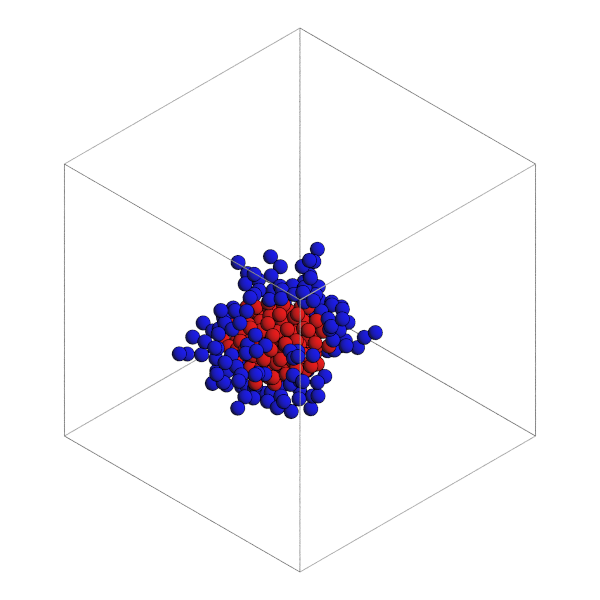

In [41]:
import os as _os
import sys as _sys
import tempfile as _tempfile
_sys.path.insert(0, _os.path.abspath('..'))
# `render_kde_images` come from the spliced campaign/featurize.py cell near the top.
from PIL import Image as _Image

# Take the final (equilibrated) frame of the block copolymer trajectory
_demo_traj = load_gsd('block_copolymer.gsd')
render_pretty(_demo_traj)
_demo_dir = _tempfile.mkdtemp(prefix='cdse_kde_demo_')
_demo_paths = render_kde_images(_demo_traj, _demo_dir, kde_sigma=2.0, img_size=224)
_demo_all_xy = next(p for p in _demo_paths if _os.path.basename(p).startswith('all_xy'))
density_image = np.array(_Image.open(_demo_all_xy))

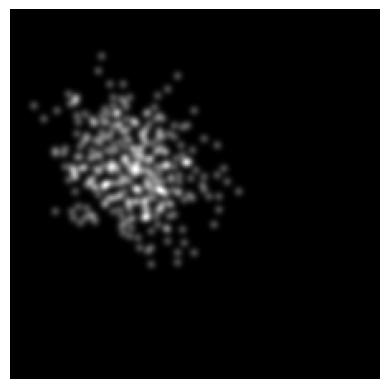

In [42]:
plt.imshow(density_image, cmap='gray')
plt.axis('off')
plt.show()

**What you should see:** a grayscale density image (the `xy` projection) with visibly blobby, high-contrast regions.

This is a real relaxed 30-chain melt from Notebook 01, rendered as a picture instead of a coordinate list.
The frame is loaded straight from `block_copolymer.gsd`, and the rendering pipeline below is exactly what every structure in this course goes through.

*How fine should the grid be, and how much should we blur?*

Both are choices, not constants.
The grid size (`img_size`) sets how finely we resolve space, and the blur width (`kde_sigma`) sets how much we smear.

Too fine a grid with too little blur gives a noisy speckle a filter can't read.
Too coarse a grid with too much blur washes the morphology into a single gray smudge.

Let's sweep both on the `0010011110` structure from Section 2 and see the tradeoff directly.

In [43]:
import os
import sys
import tempfile
sys.path.insert(0, os.path.abspath('..'))
# `render_kde_images` come from the spliced campaign/featurize.py cell near the top.
from PIL import Image

In [44]:
_sweep_traj = load_gsd('../data/kg10-gsd-bundle/gsd/0010011110_seed1.gsd')
_sweep_dir = tempfile.mkdtemp(prefix='cdse_kde_sweep_')
combos = [(32, 0.5), (32, 3.0), (224, 0.5), (224, 2.0)]
print(f'sweeping {len(combos)} (grid size, blur width) pairs on sequence 0010011110')

sweeping 4 (grid size, blur width) pairs on sequence 0010011110


In [45]:
sweep_images = []
for s, sig in combos:
    paths = render_kde_images(_sweep_traj, _sweep_dir, kde_sigma=sig, img_size=s)
    all_xy_path = next(p for p in paths if os.path.basename(p).startswith('all_xy'))
    sweep_images.append(np.array(Image.open(all_xy_path)))

print(f'{len(sweep_images)} images rendered, sizes {[im.shape[0] for im in sweep_images]}')

4 images rendered, sizes [32, 32, 224, 224]


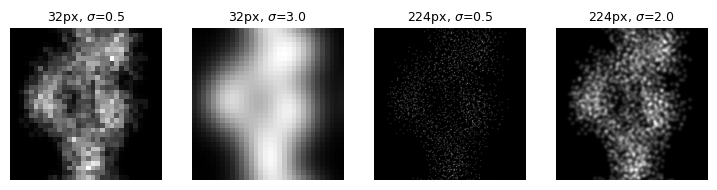

In [46]:
fig, axes = plt.subplots(1, 4, figsize=(9, 2.6))
for ax, (s, sig), img in zip(axes, combos, sweep_images):
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{s}px, $\\sigma$={sig}', fontsize=9)
    ax.axis('off')
plt.show()

The fine grid with moderate blur (rightmost) keeps domain structure distinct *and* smooth.
The coarse-sharp panel is a blocky mess, and heavy blur on a coarse grid melts everything into one gray smudge.

In practice you sweep these like any hyperparameter.
There is no physically correct resolution, only one that makes your morphologies legible to the network downstream.

Fix it once (`img_size=224, kde_sigma=2.0`, what `density_image` above already used), then use identical settings for every structure so the fingerprints stay comparable.

*Why are images the right home for this?*

Because of **convolution**, the operation a CNN is built from.

A convolution slides a small kernel $k$ over the image $I$ at every position:

$$(I * k)[i,j] = \sum_u \sum_v I[i-u, j-v]\, k[u,v]$$

In code `I` is the image, `k` the kernel, and the output is the filter's `response`.

The property that matters is **translation equivariance**: shift the input and the response shifts the same way.
That is why a filter detects a motif *wherever* it sits, with no separate detector per location.

In [47]:
from scipy.ndimage import convolve

# Use a REAL density image (the demo sequence's KDE render, loaded above) instead of a drawn square,
# and show convolution is translation-equivariant on it.
img = density_image.astype(float)
img = img / img.max()
kernel = np.array([[-1, -1, -1],
                   [-1,  8, -1],
                   [-1, -1, -1]], float)   # a hand-written edge (Laplacian-like) filter
print(f'image {img.shape}, kernel {kernel.shape}, kernel sums to {kernel.sum():.0f}')

image (224, 224), kernel (3, 3), kernel sums to 0


In [48]:
resp = convolve(img, kernel, mode='wrap')   # fire the filter across every position
print(f'response range: {resp.min():.2f} to {resp.max():.2f}')

response range: -0.43 to 0.92


In [49]:
_sh = 40
img_shift = np.roll(img, _sh, axis=1)       # translate the input by 40 pixels
resp_shift = convolve(img_shift, kernel, mode='wrap')
# the response to the shifted input IS the shifted response, over the whole image:
print("equivariant:", np.allclose(np.roll(resp, _sh, axis=1), resp_shift))

equivariant: True


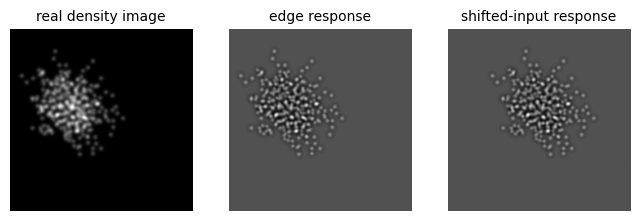

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(8, 2.9))
for ax, im, name in [(axes[0], img, 'real density image'), (axes[1], resp, 'edge response'),
                     (axes[2], resp_shift, 'shifted-input response')]:
    ax.imshow(im, cmap='gray')
    ax.set_title(name, fontsize=10)
    ax.axis('off')
plt.show()

The response to the shifted density image is the shifted response to the original, pixel for pixel, away from the wrap seam.
The printed check is `True`.

That is **equivariance**, and it is the property that makes convolution the right tool: one filter is *reused* across the entire image.
A CNN shares the same handful of kernel weights at every position, instead of learning a separate weight per pixel the way a fully-connected layer would.

Two payoffs follow.

First, drastically fewer parameters.
A $3\times3$ filter is nine numbers whether the image is $32\times32$ or $224\times224$, so the model doesn't balloon with resolution.

Second, a motif learned in one corner is automatically detected everywhere, so the network generalizes across position instead of re-learning each location from scratch.

Weight sharing is the whole reason CNNs work on images at all, and the reason we bothered turning a coordinate list into a picture in the first place.

*What do the filters learn?*

A single convolution detects one primitive: an edge at one orientation, a blob, a stripe.
Stack convolutions and the receptive field grows, so early layers compose edges into textures and later layers compose textures into motifs.

Hand-designing every filter for every scale doesn't scale, so a CNN *learns* them from data.

To see what a single layer buys us, apply a small hand-built filter bank to a density image.
Even four fixed filters expose genuinely different structure.

This is an illustrative toy, not the real network.
We are peeking at one convolution to see what the pretrained stack does hundreds of times over.

The density image itself is real: sequence `0110110110`, rendered live from its trajectory.
Two details about it:

* Heavier blur than the committed library (`kde_sigma=4.0` rather than `2.0`), so the filters respond to real domain boundaries instead of raw KDE speckle.
* Its B beads form a single connected network spanning the box (`largest_b_cluster_frac` is 1.0), which in the `xz` projection reads as two dense bands with a gap between them. That is good texture for four filters to disagree about.

In [51]:
from scipy.ndimage import convolve

In [52]:
_filter_bank_traj = load_gsd('../data/kg10-gsd-bundle/gsd/0110110110_seed1.gsd')
_filter_bank_dir = tempfile.mkdtemp(prefix='cdse_filter_bank_')
_filter_bank_paths = render_kde_images(_filter_bank_traj, _filter_bank_dir, kde_sigma=4.0, img_size=224)
_filter_bank_img_path = next(p for p in _filter_bank_paths if os.path.basename(p).startswith('all_xz'))
dens = np.array(Image.open(_filter_bank_img_path), dtype=float)
dens = dens / dens.max()

# keep the raw (pre-blur) histogram around for the scale demo below
_fb_frame = _filter_bank_traj.frames[-1]
_fb_pos = _minimum_image(_fb_frame['position'], _fb_frame['box'])
_fb_hist = _density_hist(_fb_pos[:, [0, 2]], _fb_frame['box'][[0, 2]], 224)

# A small hand-built filter bank
yy, xx = np.mgrid[-2:3, -2:3]
gabor = np.exp(-(xx**2 + yy**2) / 4.0) * np.cos(1.4 * xx)
bank = {
    'horizontal edge': np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], float),
    'vertical edge': np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], float),
    'blob (Laplacian)': np.array([[0, -1, 0], [-1, 4, -1], [0, -1, 0]], float),
    'stripe (Gabor-like)': gabor,
}
print(f'{len(bank)} filters: ' + ', '.join(bank))

4 filters: horizontal edge, vertical edge, blob (Laplacian), stripe (Gabor-like)


In [53]:
responses = {name: convolve(dens, k, mode='wrap') for name, k in bank.items()}
print("filters applied:", list(responses))

filters applied: ['horizontal edge', 'vertical edge', 'blob (Laplacian)', 'stripe (Gabor-like)']


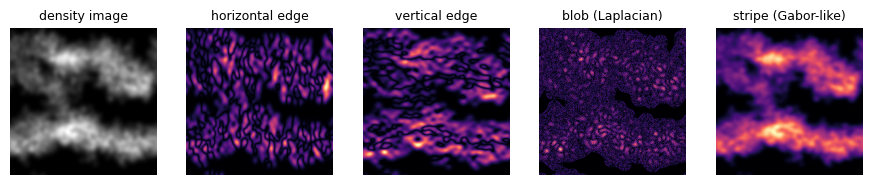

In [54]:
fig, axes = plt.subplots(1, 5, figsize=(11, 2.4))
axes[0].imshow(dens.T, origin='lower', cmap='gray')
axes[0].set_title('density image', fontsize=9); axes[0].axis('off')
for ax, (name, k) in zip(axes[1:], bank.items()):
    r = convolve(dens, k, mode='wrap')
    ax.imshow(np.abs(r).T, origin='lower', cmap='magma')
    ax.set_title(name, fontsize=9); ax.axis('off')
plt.show()

Each filter lights up a different cue.
The edge filters trace the domain boundaries, the Laplacian rings the blob cores, and the Gabor-like stripe responds to oriented texture.

Four hand-picked filters already carve the image into complementary views.
A trained CNN carries *hundreds*, tuned by data rather than guessed, and stacked so that later filters see combinations of earlier ones.

*Why not just blur harder to get cleaner filter responses?*

Because a filter only sees structure at its own scale.
The Laplacian above is 3x3, so it measures curvature over about one pixel.
Blur the image past that and there is no one-pixel curvature left to measure.

We can measure this directly.
Render the same structure at increasing blur, and ask how much of the 3x3 Laplacian's
response is real structure versus the 8-bit staircase of the saved PNG.

In [55]:
def laplacian_snr(sigma):
    """Signal-to-noise of the 3x3 Laplacian: smooth field vs its uint8 round-trip."""
    H = gaussian_filter(_fb_hist, sigma=sigma, mode='wrap')
    H = H / H.max()
    quantized = (H * 255).astype(np.uint8).astype(float) / 255
    signal = convolve(H, bank['blob (Laplacian)'], mode='wrap')
    noise = convolve(quantized, bank['blob (Laplacian)'], mode='wrap') - signal
    return np.abs(signal).std() / np.abs(noise).std()

In [56]:
for sigma in [1, 2, 4, 8, 12]:
    print(f"sigma={sigma:3d}   Laplacian SNR = {laplacian_snr(sigma):6.2f}")

sigma=  1   Laplacian SNR =  33.72
sigma=  2   Laplacian SNR =  10.12
sigma=  4   Laplacian SNR =   1.39
sigma=  8   Laplacian SNR =   0.33
sigma= 12   Laplacian SNR =   0.20


Past about `sigma=2` the fixed 3x3 Laplacian is reporting compression artifacts, not polymer structure.

The fix is not less blur. It is a bigger filter.
Scale the kernel to the blur and the signal comes back.

In [57]:
def log_kernel(scale):
    """Laplacian of Gaussian at a chosen width."""
    r = int(3 * scale)
    y, x = np.mgrid[-r:r+1, -r:r+1]
    g = np.exp(-(x**2 + y**2) / (2 * scale**2))
    k = ((x**2 + y**2) / scale**4 - 2 / scale**2) * g
    return k - k.mean()

In [58]:
_H = gaussian_filter(_fb_hist, sigma=12, mode='wrap'); _H = _H / _H.max()
_dens12 = (_H * 255).astype(np.uint8).astype(float) / 255
print(f'heavily blurred image: {_dens12.shape}, {len(np.unique(_dens12))} distinct grey levels left')

heavily blurred image: (224, 224), 254 distinct grey levels left


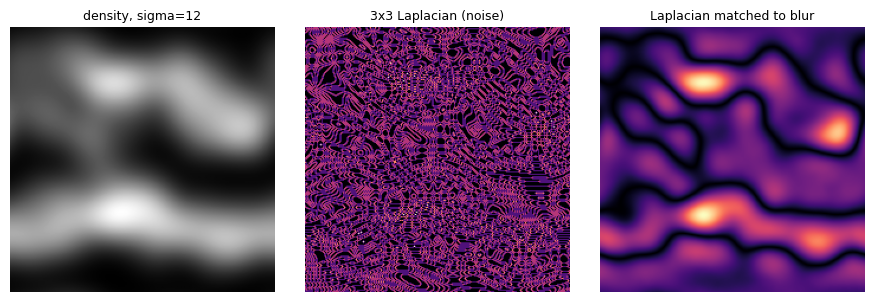

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(_dens12.T, origin='lower', cmap='gray')
axes[0].set_title('density, sigma=12', fontsize=9)
axes[1].imshow(np.abs(convolve(_dens12, bank['blob (Laplacian)'], mode='wrap')).T, origin='lower', cmap='magma')
axes[1].set_title('3x3 Laplacian (noise)', fontsize=9)
axes[2].imshow(np.abs(convolve(_dens12, log_kernel(4.0), mode='wrap')).T, origin='lower', cmap='magma')
axes[2].set_title('Laplacian matched to blur', fontsize=9)
for a in axes: a.axis('off')
plt.tight_layout()
plt.show()

That is the receptive-field argument in one figure.

A network cannot use one filter size for every scale, so it stacks layers instead.
Each layer sees combinations of the layer below, and the effective receptive field grows with depth.

So the plan is clear: render the structure, run a stack of learned filters, read out the result.

The catch is that we don't have a labeled dataset of polymer density images to train those filters on, and training a CNN from scratch on a few hundred structures would overfit instantly.

So we don't train one.
We borrow.

## [Check your understanding]

* Predict: which filter in the bank should fire most strongly on a *sharp domain boundary*, and which on a *uniform interior*?
* Build a fresh toy image (a filled circle, say) and apply the bank. Check your prediction against the responses.

> Edge filters spike at boundaries and are near zero in flat interiors.
> The blob/Laplacian filter does roughly the opposite, responding to filled cores.

*What is transfer learning?*

Most of a CNN's layers don't learn "cat-ness."
They learn generic visual primitives, edges and blobs and textures, that show up in *any* image.

So a network pretrained on ImageNet (Deng et al. 2009) already contains filters useful for our density maps, even though it has never seen a polymer.
Reusing those pretrained filters on a new problem without retraining is exactly the transfer learning move.
It's what lets us bolt a photo-classification network onto a soft-matter problem it was never designed for.

Concretely: load **EfficientNet-B0** (Tan & Le 2019), then delete its classification head with `net.classifier = torch.nn.Identity()`.

The classifier is the last layer, the part turning the network's internal representation into a "cat" versus "dog" decision.
Replacing it with `Identity()` throws that decision away and exposes what sits underneath: the **penultimate layer's** activations, a 1280-dimensional vector summarizing what the filters noticed about texture and shape, uncollapsed to a label.

One framing note.
A generic ImageNet-pretrained CNN used this way is a defensible transfer-learning choice for density images, and it is standard practice.

But it is not a reproduction of Statt, Kleeblatt & Reinhart (2021).
That paper builds rotation-invariant local three-body features, pools them with a KDE, and embeds with a local/global UMAP, a more specialized pipeline than "render an image, run a pretrained photo classifier."

We borrow their problem, not their machinery.

In [60]:
from torchvision import models, transforms

# Load EfficientNet-B0 ONCE (not rebuilt per structure -- rebuilding the model
# per call is what made an earlier version of campaign/featurize.py::extract_features
# slow: ~23s for 64 sequences vs ~15s with the model built once and inference
# batched, benchmarked on this workshop's images). Single-threaded is also
# faster than multi-threaded here: at these tiny batch sizes, thread-launch
# overhead dominates the actual compute (measured ~18.5s at 1 thread vs ~96s
# at 8 threads for batch=1 over the same image set). Do not parallelize.
torch.set_num_threads(1)
weights = models.EfficientNet_B0_Weights.DEFAULT
net = models.efficientnet_b0(weights=weights)
net.classifier = torch.nn.Identity()  # drop the classification head -> keep 1280-dim features
net.eval()

# The network expects a 3-channel 224x224 tensor; our KDE images are single-channel
# grayscale. It also expects inputs standardized to ImageNet's own per-channel
# mean/std -- skipping this (a real bug in the pre-fix pipeline) silently shifts
# every activation the pretrained filters were tuned to expect.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [61]:
def extract_batch(images, batch_size=8):
    """Extract 1280-dim features for a list of density images, batched.

    Measured fastest at batch~=8 on CPU: batch=1 (one image per forward pass)
    and one giant batch of everything at once were BOTH slower (~14.65s for
    576 images at batch=8, vs ~34-40s for the single-giant-tensor case).
    """
    feats = []
    with torch.no_grad():
        for i in range(0, len(images), batch_size):
            chunk = images[i:i + batch_size]
            batch = torch.stack([preprocess(im) for im in chunk])
            feats.append(net(batch).numpy())
    return np.concatenate(feats, axis=0)

In [62]:
features = extract_batch([density_image])[0]   # a batch of one structure -> (1280,)
print("Feature vector shape:", features.shape)

Feature vector shape: (1280,)


**What you should see:** a single printed line, `Feature vector shape: (1280,)`.

In our global notation this vector is $x \in \mathbb{R}^{1280}$; in code it is `features`.

There is nothing to read by eye, and that's the point.
This vector isn't meant to be inspected entry by entry, since no coordinate is "the vesicle-ness."
It's meant to be *compared*, mathematically, against thousands of others like it.

One honest caveat.

Transfer works here because morphology reads as *texture*, and texture is exactly what natural-image filters encode, so ImageNet features carry over cleanly.

Had our structures looked nothing like natural-image statistics, sparse line drawings say, the borrowed filters could have fired on nothing useful and the fingerprint would carry little signal.
Transfer is a bet on shared visual statistics, not a guarantee (Yosinski et al. 2014).

# 5. The 1280-dimensional fingerprint

The fingerprint is now our unit of comparison.
The *same* frozen network turns every structure into a vector in the same 1280-dimensional space, so two structures are comparable by a simple distance.

That "same frozen network for everything" is the whole point.
It's what makes two fingerprints commensurable at all.

A natural distance for these vectors is **cosine distance**:

$$d(\mathbf{x}_a, \mathbf{x}_b) = 1 - \frac{\mathbf{x}_a\cdot\mathbf{x}_b}{\lVert\mathbf{x}_a\rVert\,\lVert\mathbf{x}_b\rVert}$$

It is zero when two fingerprints point the same way, and larger as they diverge.
It compares *direction* rather than magnitude, which is what we want when the overall activation scale carries less meaning than the pattern across features.

In code $\mathbf{x}_a$ and $\mathbf{x}_b$ are `x` and `x_alt`.

In [63]:
x = features                 # our fingerprint: x in R^1280 (global notation)
print(x.shape, x[:5])

(1280,) [-0.13249353 -0.07238299 -0.22328708 -0.06955216 -0.07785292]


Just a flat array of 1280 floats.
No axis labels, no units, nothing you would hand a labmate and expect them to read.

Its meaning lives entirely in *comparison*.
The geometry of where this point sits relative to other fingerprints is the whole signal.

So let's produce a second fingerprint and measure a distance, using the two campaign sequences from Section 2, `0010011110` and `0110101101`.
That pair is the better demo.
It is already the same-$R_g^2$, different-shape pair, so a nonzero fingerprint distance is telling us something $R_g^2$ alone could not.

In [64]:
# Fingerprint both Section-2 structures through the same periodic-aware
# renderer as Section 4. Section 2's `pos` is *unwrapped* (needed for a
# PBC-artifact-free Rg^2); re-wrapping it via minimum-image before
# histogramming is required here -- these aggregates span well past the box
# (up to ~20 vs. box/2 ~= 11.75), so histogramming the raw unwrapped cloud
# would silently drop most of the beads outside [-box/2, box/2], the same
# particle-dropping failure mode the periodic KDE renderer exists to avoid.
# `_kde_image, _minimum_image` come from the spliced campaign/featurize.py cell near the top.
_pair_images = []
for seq in _pair:
    pos = _minimum_image(structures[seq]['pos'], structures[seq]['box'])
    box = structures[seq]['box']
    _pair_images.append(_kde_image(pos[:, [0, 1]], box[[0, 1]], img_size=224, kde_sigma=2.0))

print(f'{len(_pair_images)} density images, each {_pair_images[0].shape}')

2 density images, each (224, 224)


In [65]:
# Batch both fingerprints in ONE call (batch of 2 here; the real 64-sequence x
# 9-image pipeline batches in groups of ~8) -- net and preprocess are the same
# frozen objects instantiated once in Section 4, never rebuilt.
x, x_alt = extract_batch(_pair_images)
print(f'two fingerprints, each {x.shape[0]} numbers long')

two fingerprints, each 1280 numbers long


In [66]:
def cosine_distance(a, b):
    return 1 - np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

print(f"d({_pair[0]}, {_pair[0]}) = {cosine_distance(x, x):.4f}")           # self-distance ~ 0
print(f"d({_pair[0]}, {_pair[1]}) = {cosine_distance(x, x_alt):.4f}")

d(0010011110, 0010011110) = 0.0000
d(0010011110, 0110101101) = 0.2078


Two numbers: a structure sits at distance near 0 from itself, which is the sanity check, and clearly positive from the other real sequence.

On its own that second number demonstrates nothing.
*Any* two distinct fingerprints normally have nonzero cosine distance, so one positive value cannot show the CNN cleanly separates morphology.

Let's check properly, using images already rendered for other real campaign sequences.
We compare two things:

* **within-sequence**: one structure's three fixed viewing angles (`xy`, `xz`, `yz`), the same aggregate seen from different cameras
* **between-sequence**: fingerprint distances between genuinely different sequences.

In [67]:
# Real validation of the "similar structures land close" claim: within-sequence
# (same aggregate, three different viewing angles) vs. between-sequence (different
# real campaign structures) cosine-distance spread, using images already rendered
# on disk -- no new simulation or rendering needed.
_val_seqs = ['0010011110', '0110101101', '0000000000', '1111111111', '0101010101', '0011100011']
_views = ['xy', 'xz', 'yz']
_val_feats = {}
for seq in _val_seqs:
    imgs = [np.array(Image.open(f'{EXHAUSTIVE_DIR}/_images/{seq}/all_{v}_cv2_kde_sigma_2.0_size_224.webp'))
            for v in _views]
    _val_feats[seq] = extract_batch(imgs)   # (3, 1280): one row per view

print(f'fingerprinted {len(_val_feats)} sequences x 3 views = {3*len(_val_feats)} vectors')

fingerprinted 6 sequences x 3 views = 18 vectors


In [68]:
_within = [cosine_distance(f[i], f[j])
           for f in _val_feats.values()
           for i in range(3) for j in range(i + 1, 3)]
_between = [cosine_distance(_val_feats[a][i], _val_feats[b][j])
            for ai, a in enumerate(_val_seqs) for b in _val_seqs[ai + 1:]
            for i in range(3) for j in range(3)]
_within, _between = np.array(_within), np.array(_between)
print(f"within-sequence (same structure, different view):  "
      f"mean={_within.mean():.4f}  max={_within.max():.4f}   (n={len(_within)})")
print(f"between-sequence (different real structures):        "
      f"mean={_between.mean():.4f}  min={_between.min():.4f}   (n={len(_between)})")

within-sequence (same structure, different view):  mean=0.3125  max=0.7217   (n=18)
between-sequence (different real structures):        mean=0.4930  min=0.0969   (n=135)


Now a real check rather than one anecdote.
On this six-sequence spot check:

* **within-sequence** (same aggregate, different camera angle): about 0.31
* **between-sequence** (different real structures): about 0.49

On average the fingerprint tracks morphological identity more than viewing angle, which supports the nearest-neighbors-look-alike property.

But the separation is *not* clean.
The largest within-sequence distance sits well above the smallest between-sequence one, so some structures viewed from different angles look more different to the network than some genuinely different structures do.

"Tends to separate morphology, on average" is supported.
"Cleanly separates" is not, and six sequences is a spot check, not a retrieval-precision study.

This pipeline answers the *same question* Statt et al. (2021) asked, namely how to featurize copolymer-aggregation structure without a hand-designed order parameter.
But it is not a reproduction of their method.

* **Theirs:** rotation-invariant local three-body features, KDE-pooled, embedded with local/global UMAP.
* **Ours:** render an image, borrow a pretrained classifier's filters.

Ours is coarser and much simpler, but the philosophy is the same: the descriptor is *learned* rather than guessed.

This notebook is the second half of what Day 1 called the **oracle**, which is MD plus featurization.
We demonstrated it on real campaign trajectories, and the identical pipeline featurizes the `.gsd` file *you* generated in Notebook 02.

From here, Notebook 05 pools those per-frame fingerprints into one vector per sequence.
Day 2 then stacks one row $x$ per structure into a feature matrix, folding it down to a 2-D latent coordinate $z \in \mathbb{R}^2$ you can plot.

## [Check your understanding]

* You'll fingerprint a *third* structure. Use `single_chain.gsd`, or any other sequence from `data/kg10-gsd-bundle` (`fetch_gsd_for_sequence('0110010111')` from `data_bootstrap.py` fetches any of the 528 canonical sequences on demand). Before you run it, predict whether its fingerprint lands closer to `0010011110` or `0110101101`, and why.
* Render it, extract its fingerprint through `extract_batch` (the same frozen `net`), and compute the cosine distance to both `x` and `x_alt`. Was your prediction right?

> If distance tracks morphology, the third structure sits nearer whichever of the two it visually resembles.
> That's the property the whole pipeline is betting on.

## References

* Statt, A.; Kleeblatt, D. C.; Reinhart, W. F. Unsupervised learning of sequence-specific aggregation behavior for a model copolymer. *Soft Matter* **2021**, *17*, 7697-7707. https://doi.org/10.1039/d1sm01012c
  Sections 2 and 5. Motivates the featurization problem this notebook tackles with a different, simpler pipeline.
* Bhattacharya, D.; Kleeblatt, D. C.; Statt, A.; Reinhart, W. F. Predicting aggregate morphology of sequence-defined macromolecules with recurrent neural networks. *Soft Matter* **2022**, *18*, 5037-5051. https://doi.org/10.1039/d2sm00452f
  The Day 2 surrogate that consumes these fingerprints' embedding.
* Reinhart, W. F. Unsupervised learning of atomic environments from simple features. *Comput. Mater. Sci.* **2021**, *196*, 110511. https://doi.org/10.1016/j.commatsci.2021.110511
  Section 4. A generic learned representation in place of a hand-designed order parameter.
* Tan, M.; Le, Q. V. EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks. *Proc. 36th ICML* **2019**, PMLR 97, 6105-6114. arXiv:1905.11946
  Section 4. The network we load, `efficientnet_b0`.
* Deng, J.; Dong, W.; Socher, R.; Li, L.-J.; Li, K.; Fei-Fei, L. ImageNet: A Large-Scale Hierarchical Image Database. *CVPR* **2009**, 248-255. https://doi.org/10.1109/CVPR.2009.5206848
  Section 4. The pretraining corpus whose generic filters transfer.
* Yosinski, J.; Clune, J.; Bengio, Y.; Lipson, H. How transferable are features in deep neural networks? *NeurIPS* **2014**, 27, 3320-3328. arXiv:1411.1792
  Section 4. The "when transfer fails" caveat.
* Rubinstein, M. & Colby, R. H. *Polymer Physics* (Oxford University Press, 2003).
  Standard polymer-physics reference for the $R_g$ and descriptor material in Sections 1 and 2.